In [91]:
import numpy as np
import fitsio
from astropy.table import Table,vstack,join,unique
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import scienceplots
plt.style.use(['science','grid','notebook'])

from matplotlib.colors import LogNorm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from astropy.io import fits
import sys
sys.path.append('/user/animesh.sah/DESI_PECVEL')
original_sys_path = sys.path.copy()
from Metrics import PhotoZMetrics
sys.path = original_sys_path


In [92]:
DR1_SGC=Table(fitsio.FITS('../desi_dr1_SGC.fits')[1].read())
DR1_NGC=Table(fitsio.FITS('../desi_dr1_NGC.fits')[1].read())
DR1=vstack([DR1_NGC,DR1_SGC])
print(len(DR1))

#sanity checks

DR1_unique = unique(DR1,['TARGETID']) 
_, unique_indices = np.unique(DR1['TARGETID'], return_index=True)
print(f"Original DR1 length: {len(DR1)}")
print(f"DR1_unique length: {len(DR1_unique)}")
print(f"Unique indices shape: {unique_indices.shape}")
del(DR1_unique)


5522353
Original DR1 length: 5522353
DR1_unique length: 5522353
Unique indices shape: (5522353,)


In [93]:
north = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v10_flux_w1.fits')[1].read())
south = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits')[1].read())
combined = vstack([north,south])
table_selection = Table(fitsio.FITS('../table_match_final.fits')[1].read())
common = join(
    table_selection,
    combined,
    keys=['BRICKID','OBJID','BRICKNAME'],
    join_type='inner'
)

In [94]:
coords_dr = SkyCoord(ra=DR1['RA']*u.deg, dec=DR1['DEC']*u.deg)
coords_legacy = SkyCoord(ra=common['RA_1']*u.deg, dec=common['DEC_1']*u.deg)
idx_legacy, idx_dr, sep2d, _ = coords_dr.search_around_sky(coords_legacy, 1.5*u.arcsec)
matched_dr = DR1[idx_dr]
matched_FP = common[idx_legacy]

In [95]:
cols_to_remove = [col for col in matched_FP.colnames if col.endswith('_2')]
matched_FP.remove_columns(cols_to_remove)

cols_to_rename = {col: col[:-2] for col in matched_FP.colnames if col.endswith('_1')}
matched_FP.rename_columns(tuple(cols_to_rename.keys()), tuple(cols_to_rename.values()))

In [96]:
def two_d_hist(x,y):
    binx = np.linspace((min(x)), max(x), 50)
    biny = np.linspace((min(y)), max(y), 50)
    hist, xedges, yedges = np.histogram2d(x, y, bins=[binx, biny])
    return hist, xedges, yedges

/tmp/ipykernel_1632421/3187994188.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, 'Photo Z (Legacy)')

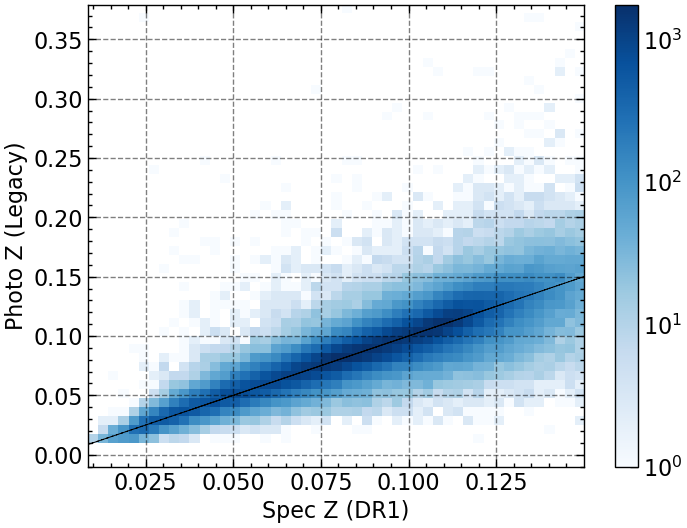

In [97]:
binx = np.linspace(min(matched_FP['Z_PHOT_MEDIAN']), max(matched_FP['Z_PHOT_MEDIAN']), 50)
biny = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_FP['Z_PHOT_MEDIAN'], matched_dr['Z'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues',norm=LogNorm())

plt.plot(matched_FP['Z_PHOT_MEDIAN'],matched_FP['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('Photo Z (Legacy)')

In [101]:
# Save the matched tables to FITS files
matched_FP.write('matched_FP.fits', overwrite=True)
matched_dr.write('matched_dr.fits', overwrite=True)

print(f"Saved matched_FP with {len(matched_FP)} objects to 'matched_FP.fits'")
print(f"Saved matched_dr with {len(matched_dr)} objects to 'matched_dr.fits'")

Saved matched_FP with 133625 objects to 'matched_FP.fits'
Saved matched_dr with 133625 objects to 'matched_dr.fits'


Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (FP sample)')

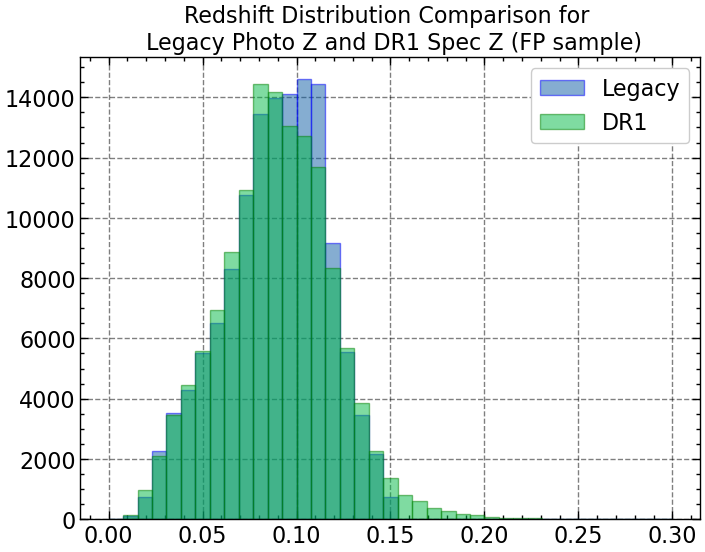

In [99]:
bins = np.linspace(0,0.3,40)
plt.hist(matched_FP['Z_PHOT_MEDIAN'], bins=bins, alpha=0.5, label='Legacy',edgecolor='blue')  
plt.hist(matched_dr['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')
plt.legend()
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (FP sample)')


In [100]:
def add_colors(table):
    MAG = {}
    FIBERMAG = {}
    MAG_NOEXT={}
    for i in ['G','R','Z','W1','W2','W3']:
        flux = np.array(table[f'FLUX_{i}'])
        trans = np.array(table[f'MW_TRANSMISSION_{i}'])
        frac = flux / trans
        mag = np.empty_like(frac)
        mag_noext = np.empty_like(frac)
        np.log10(flux, out=mag_noext, where=(frac > 0))
        np.log10(frac, out=mag, where=(frac > 0))
        MAG[i] = 22.5 - 2.5 * mag
        MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext

    table['MAG_G'] = MAG['G']
    table['MAG_R'] = MAG['R']
    table['MAG_Z'] = MAG['Z']
    table['MAG_W1'] = MAG['W1']
    table['MAG_W2'] = MAG['W2']
    table['MAG_W3'] = MAG['W3']

    table['MAG_GR'] = table['MAG_G'] - table['MAG_R']
    table['MAG_RZ'] = table['MAG_R'] - table['MAG_Z']
    table['MAG_GZ'] = table['MAG_G'] - table['MAG_Z']
    table['MAG_W1W2'] = table['MAG_W1'] - table['MAG_W2']
    table['MAG_W2W3'] = table['MAG_W2'] - table['MAG_W3']
    table['MAG_W1W3'] = table['MAG_W1'] - table['MAG_W3']
    table['MAG_RW1'] = table['MAG_R'] - table['MAG_W1']
    table['MAG_RW2'] = table['MAG_R'] - table['MAG_W2']
    table['MAG_RW3'] = table['MAG_R'] - table['MAG_W3']
    table['MAG_GW1'] = table['MAG_G'] - table['MAG_W1']
    table['MAG_GW3'] = table['MAG_G'] - table['MAG_W3']
    table['MAG_GW2'] = table['MAG_G'] - table['MAG_W2']
    table['MAG_ZW1'] = table['MAG_Z'] - table['MAG_W1']
    table['MAG_ZW2'] = table['MAG_Z'] - table['MAG_W2']
    table['MAG_ZW3'] = table['MAG_Z'] - table['MAG_W3']
    return table

def compute_magnitudes( legacy):
        """Compute magnitudes and color indices from flux measurements"""
        print("Computing magnitudes and colors...")
        
        MAG = {}
        MAG_NOEXT = {}
        
        for band in ['G', 'R', 'Z', 'W1', 'W2', 'W3']:
            flux = np.array(legacy[f'FLUX_{band}'])
            trans = np.array(legacy[f'MW_TRANSMISSION_{band}'])
            frac = flux / trans
            valid = (frac > 0) & np.isfinite(frac)

            mag = np.full_like(frac, fill_value=np.nan)
            mag_noext = np.full_like(frac, fill_value=np.nan)
            
            # Handle zero/negative fluxes
            
            np.log10(flux, out=mag_noext, where=valid)
            np.log10(frac, out=mag, where=valid)

            MAG[band] = 22.5 - 2.5 * mag
            MAG_NOEXT[band] = 22.5 - 2.5 * mag_noext
            
            legacy[f'MAG_{band}'] = MAG[band]

        # Compute color indices

        color_combinations = [
            ('G', 'R'), ('R', 'Z'), ('G', 'Z'),
            ('W1', 'W2'), ('W2', 'W3'), ('W1', 'W3'),
            ('R', 'W1'), ('R', 'W2'), ('R', 'W3'),
            ('G', 'W1'), ('G', 'W2'), ('G', 'W3'),
            ('Z', 'W1'), ('Z', 'W2'), ('Z', 'W3')
        ]
        
        for band1, band2 in color_combinations:
            legacy[f'MAG_{band1}{band2}'] = legacy[f'MAG_{band1}'] - legacy[f'MAG_{band2}']
        #legacy = self._add_features(legacy)
        
        return legacy

#matched_FP = add_colors(matched_FP)

matched_FP = compute_magnitudes(matched_FP)

def _add_features( legacy):
    """Add additional features to the dataset"""
    e1,e2 = legacy['SHAPE_E1'], legacy['SHAPE_E2']
    epsilon = np.sqrt(e1**2 + e2**2)
    bba = (1 - epsilon) / (1 + epsilon)
    r_circ = np.sqrt(bba) * legacy['SHAPE_R']
    legacy['BBA'] = bba
    legacy['R_CIRC'] = r_circ
    return legacy

matched_FP = _add_features( matched_FP)


Computing magnitudes and colors...


In [148]:
from catboost import CatBoostRegressor  
model = CatBoostRegressor() 
model.load_model("/user/animesh.sah/DESI_PECVEL/notebooks/catboost_model_full_features_mag_typeser_with_shapes_z_weighted_sigmoid.cbm")
# model.load_model("/user/animesh.sah/DESI_PECVEL/notebooks/catboost_model_full_features_mag_typeser_with_shapes_z_FP_sample.cbm")
# model.load_model("/user/animesh.sah/DESI_PECVEL/notebooks/catboost_model_full_features_mag_typeser_with_shapes_z_weighted_FP.cbm")
# model.load_model("/user/animesh.sah/DESI_PECVEL/notebooks/catboost_model_full_features_mag_typeser_with_shapes.cbm")
y = matched_dr['Z']
feature_names =['MAG_G','MAG_R','MAG_Z','MAG_W1','MAG_W2','MAG_W3','MAG_GR','MAG_RZ','MAG_GZ','MAG_W1W2','MAG_W2W3','MAG_W1W3','MAG_RW1','MAG_RW2','MAG_RW3','MAG_GW1','MAG_GW2','MAG_GW3','MAG_ZW1','MAG_ZW2','MAG_ZW3','R_CIRC','BBA','SHAPE_E1','SHAPE_E2','SERSIC','TYPE']
X = matched_FP[feature_names].to_pandas().to_numpy()
z_pred=model.predict(X)


/tmp/ipykernel_1632421/2511889572.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'CatBoost predicted')
/tmp/ipykernel_1632421/2511889572.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'Photo Z legacy')


Text(0.5, 0, 'Spec Z (DR1)')

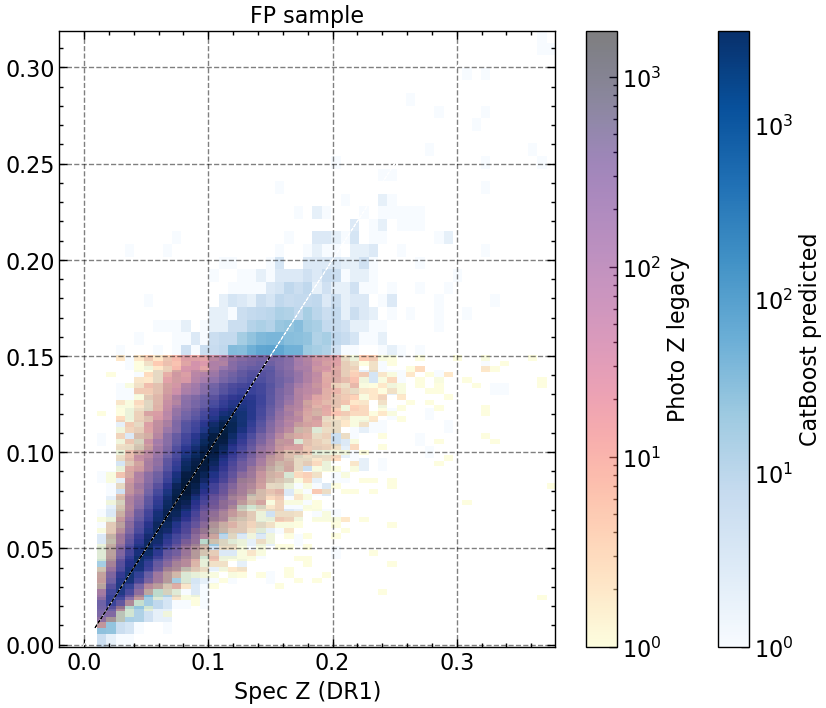

In [149]:
from matplotlib.colors import LogNorm

binx = np.linspace(min(matched_dr['Z']), 
                    max(matched_dr['Z']), 50)
biny = np.linspace(min(z_pred), 
                    max(z_pred), 50)
hist, xedges, yedges = np.histogram2d(matched_dr['Z'], 
                                        z_pred, 
                                        bins=(binx, biny))

# Log scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='Blues', norm=LogNorm())
plt.plot(z_pred, z_pred, 'w--', lw=0.7)
plt.colorbar(label = 'CatBoost predicted')
plt.title('FP sample')
plt.xlabel('Z (DR1)')


biny = np.linspace(min(matched_FP['Z_PHOT_MEDIAN']), max(matched_FP['Z_PHOT_MEDIAN']), 50)
binx = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm(),alpha=0.5)

plt.plot(matched_FP['Z_PHOT_MEDIAN'],matched_FP['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar(label = 'Photo Z legacy')
plt.xlabel('Spec Z (DR1)')




/tmp/ipykernel_1632421/2511889572.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'CatBoost predicted')
/tmp/ipykernel_1632421/2511889572.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label = 'Photo Z legacy')


Text(0.5, 0, 'Spec Z (DR1)')

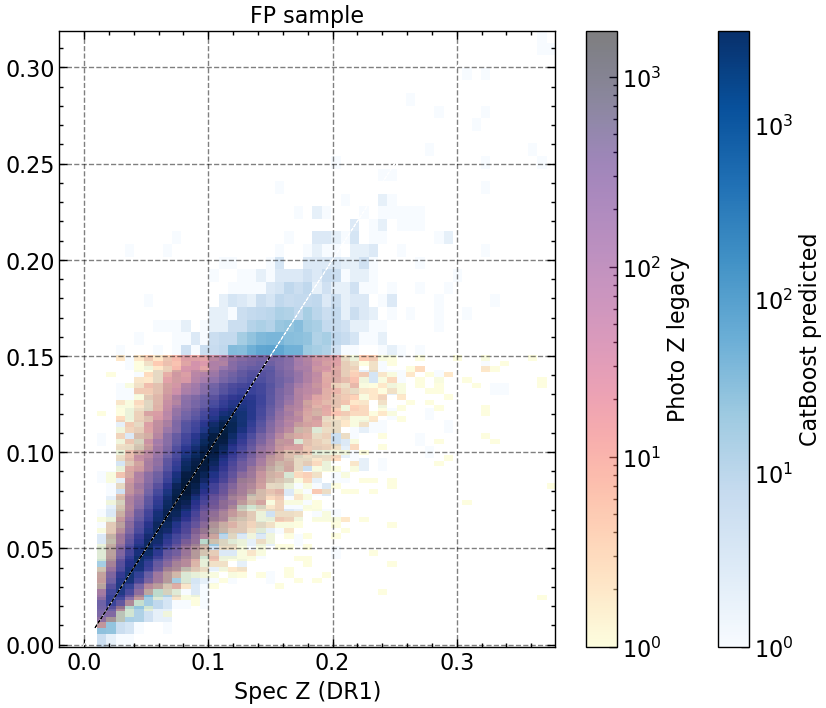

In [150]:
from matplotlib.colors import LogNorm

binx = np.linspace(min(matched_dr['Z']), 
                    max(matched_dr['Z']), 50)
biny = np.linspace(min(z_pred), 
                    max(z_pred), 50)
hist, xedges, yedges = np.histogram2d(matched_dr['Z'], 
                                        z_pred, 
                                        bins=(binx, biny))

# Log scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='Blues', norm=LogNorm())
plt.plot(z_pred, z_pred, 'w--', lw=0.7)
plt.colorbar(label = 'CatBoost predicted')
plt.title('FP sample')
plt.xlabel('Z (DR1)')


biny = np.linspace(min(matched_FP['Z_PHOT_MEDIAN']), max(matched_FP['Z_PHOT_MEDIAN']), 50)
binx = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm(),alpha=0.5)

plt.plot(matched_FP['Z_PHOT_MEDIAN'],matched_FP['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar(label = 'Photo Z legacy')
plt.xlabel('Spec Z (DR1)')




In [113]:
metric = PhotoZMetrics(matched_dr['Z'], z_pred)

In [114]:
print('MSE for Catboost :',mean_squared_error(matched_dr['Z'], z_pred))
print('MAE for Catboost :',mean_absolute_error(matched_dr['Z'], z_pred))
print('R2 for Catboost :',r2_score(matched_dr['Z'], z_pred))
print('Photo Z metrics')
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.0002687287102231233
MAE for Catboost : 0.011614468390894401
R2 for Catboost : 0.7074410853233684
Photo Z metrics
bias for Catboost: 0.001990195041551222
sigma for Catboost: 0.0147066205119115
sigma_NMAD for Catboost: 0.01128653811353895
delta(0.3) for Catboost: 1.0
outlier_fraction(0.15) for Catboost: 2.9934518241347055e-05
------------------------------------------------------------
MSE for Legacy : 0.0002441843739725424
MAE for Legacy : 0.010213853906576498
R2 for Legacy : 0.7341619532535801
Photo Z metrics
bias for Legacy: 0.0008314622342067523
sigma for Legacy: 0.013973478192479374
sigma_NMAD for Legacy: 0.009271032751232509
delta(0.3) for Legacy: 1.0
outlier_fraction(0.15) for Legacy: 0.00010477081384471468


In [13]:
print('MSE for Catboost :',mean_squared_error(matched_dr['Z'], z_pred))
print('MAE for Catboost :',mean_absolute_error(matched_dr['Z'], z_pred))
print('R2 for Catboost :',r2_score(matched_dr['Z'], z_pred))
print('Photo Z metrics')
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(matched_dr['Z'], matched_FP['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.0002442737027901704
MAE for Catboost : 0.011029510295661963
R2 for Catboost : 0.7340647029749892
Photo Z metrics
bias for Catboost: 0.002066444083379625
sigma for Catboost: 0.014003684568925456
sigma_NMAD for Catboost: 0.010576451321643091
delta(0.3) for Catboost: 1.0
outlier_fraction(0.15) for Catboost: 2.245088868101029e-05
------------------------------------------------------------
MSE for Legacy : 0.0002441843739725424
MAE for Legacy : 0.010213853906576498
R2 for Legacy : 0.7341619532535801
Photo Z metrics
bias for Legacy: 0.0008314622342067523
sigma for Legacy: 0.013973478192479374
sigma_NMAD for Legacy: 0.009271032751232509
delta(0.3) for Legacy: 1.0
outlier_fraction(0.15) for Legacy: 0.00010477081384471468


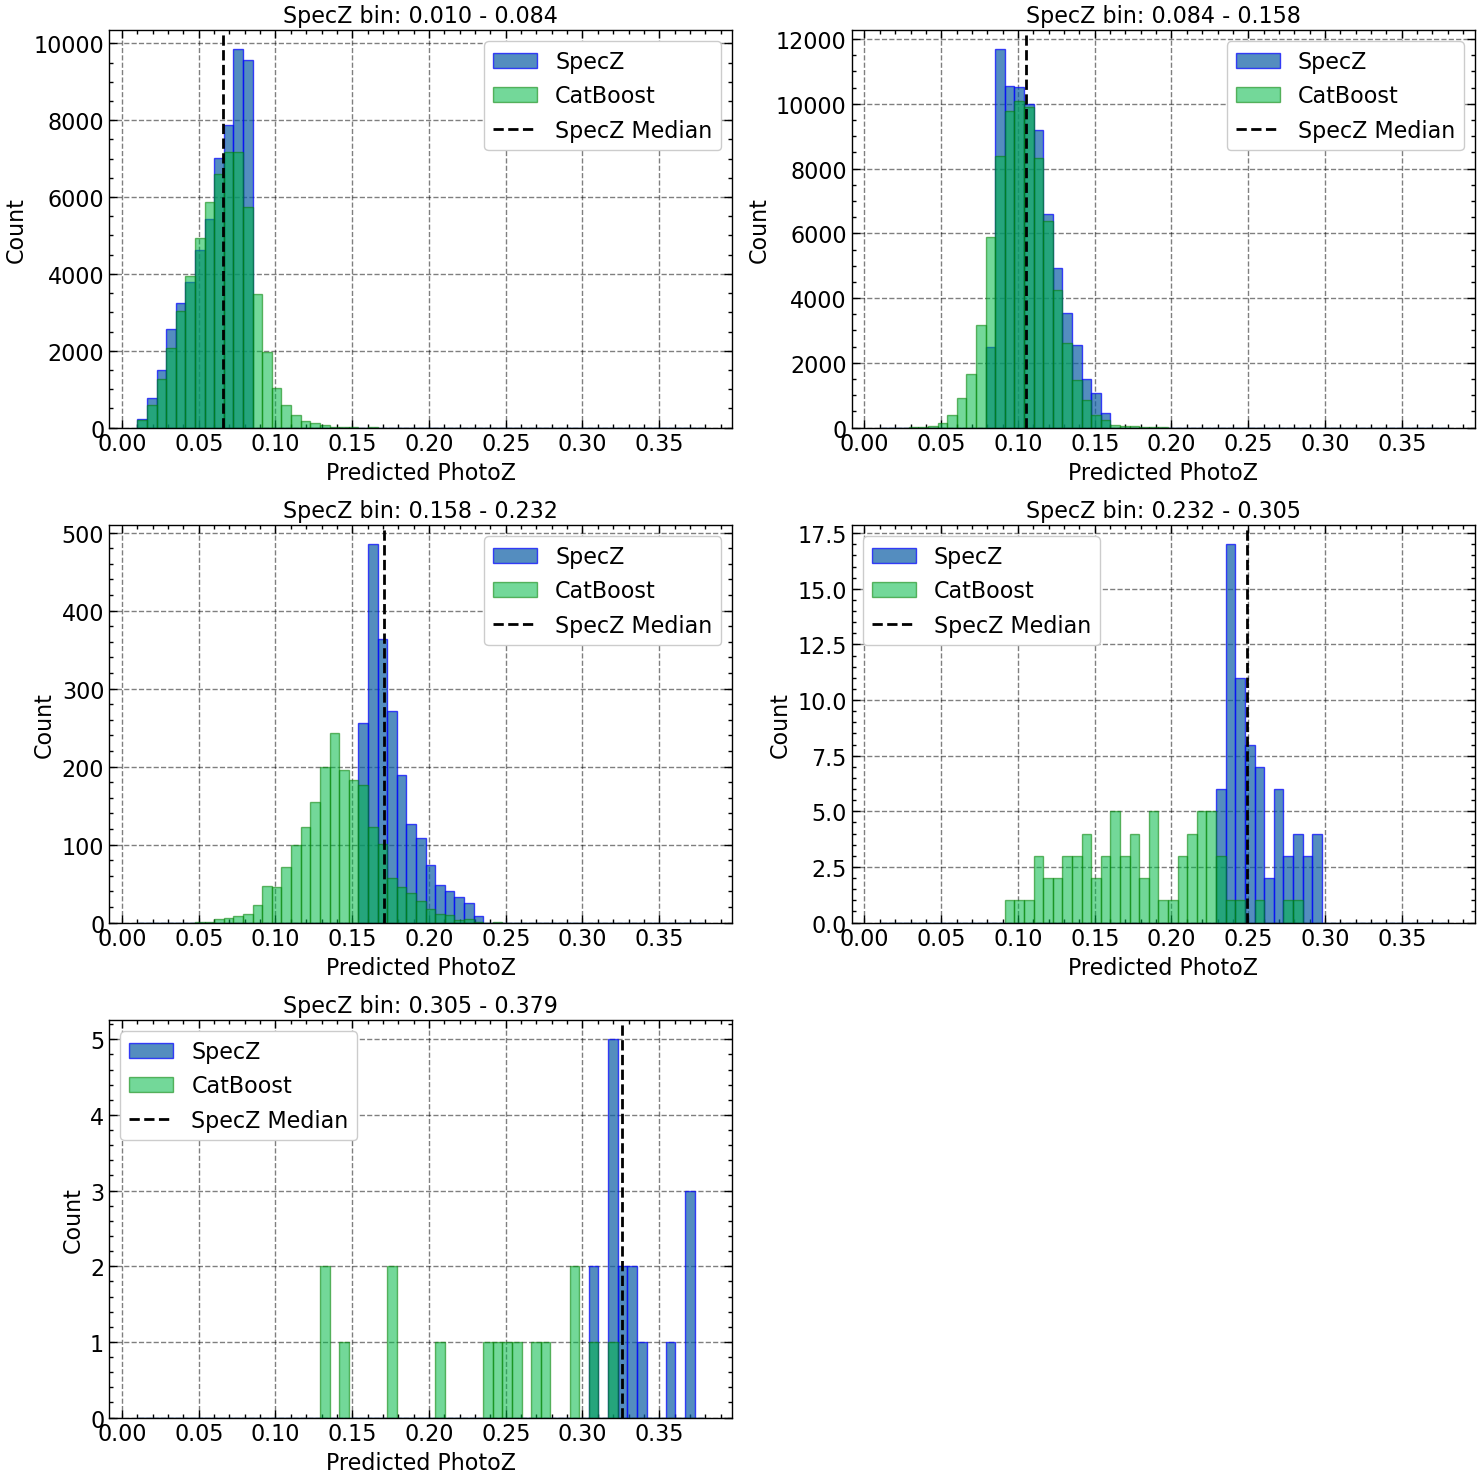

In [17]:
nbins = 5 
zbins = np.linspace(np.min(matched_dr['Z']), np.max(matched_dr['Z']), nbins+1)
bin_indices = np.digitize(matched_dr['Z'], zbins)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin = z_pred[mask]
    spec_z_bin = matched_dr['Z'][mask]
    bin_hist = np.linspace(zbins[0], zbins[-1], 60)
    axes[i-1].hist(spec_z_bin, bins=bin_hist, alpha=0.7, label='SpecZ', edgecolor='blue')
    axes[i-1].hist(phot_z_bin, bins=bin_hist, alpha=0.55, label='CatBoost', edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')

# Hide the last subplot since we only have 5 bins
axes[5].axis('off')

plt.tight_layout()
plt.show()

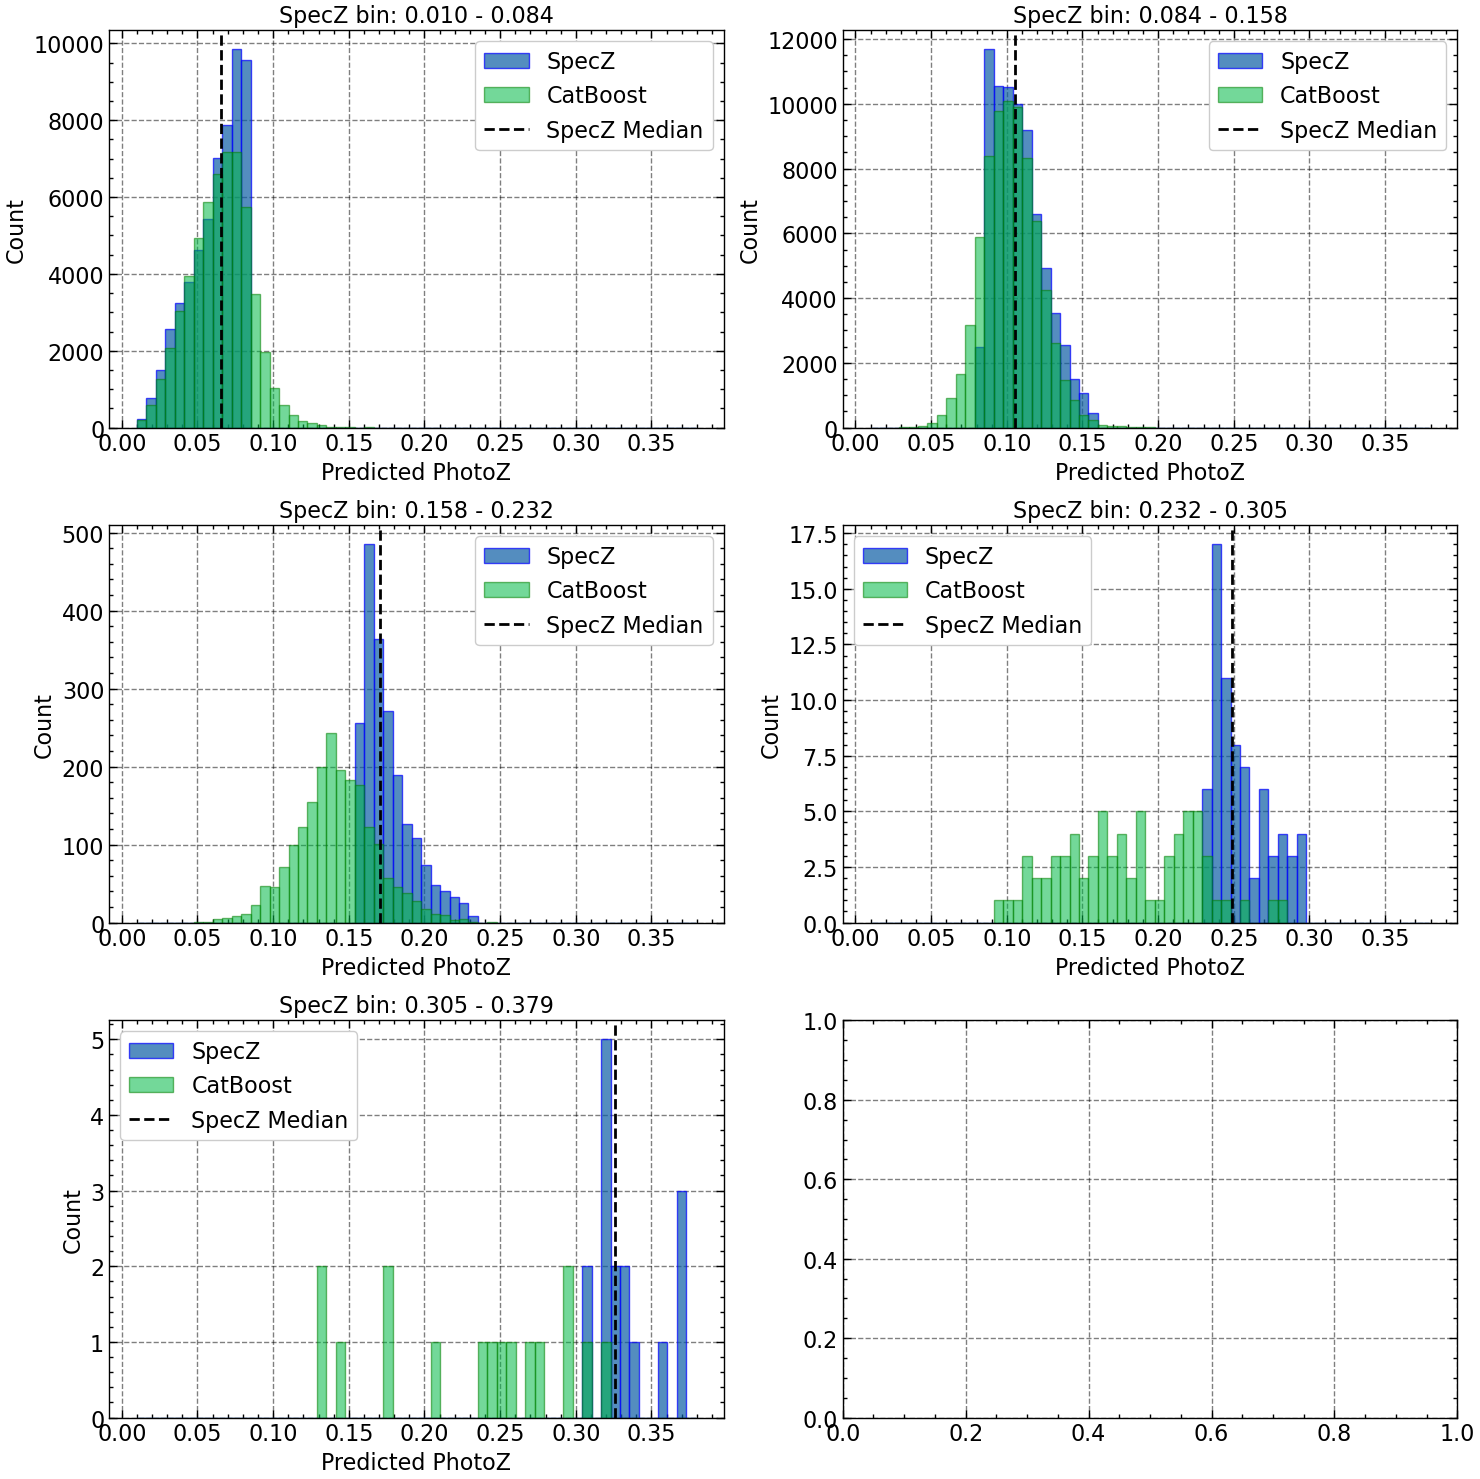

In [18]:
nbins = 5 
zbins = np.linspace(np.min(matched_dr['Z']), np.max(matched_dr['Z']), nbins+1)
bin_indices = np.digitize(matched_dr['Z'], zbins)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = z_pred[mask]
    spec_z_bin = matched_dr['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='CatBoost',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

In [119]:
matched_dr['Z']

0.1436762268302619
0.11857213914442365
0.12012437783350197
0.10776745157591323
0.0870032736141592
0.0870032736141592
0.10830805288753834
0.07336701173362334
0.16200132679681517
0.15533154390547288
0.09968328705594647


In [130]:
bins

array([0.01003037, 0.0642266 , 0.08237332, 0.09708281, 0.11358629,
       0.37926065])

In [140]:
df['bin'].unique()

array([4, 3, 2, 1, 0])

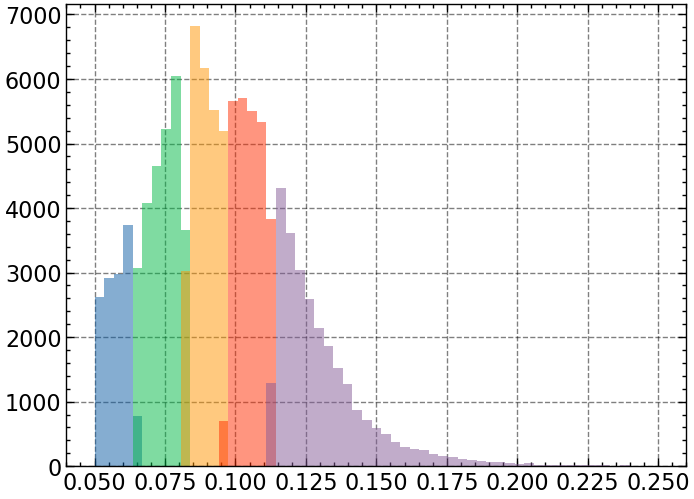

In [139]:

for i in range(0, nbins+1):
    mask = df['bin'] == i
    bins = np.linspace(0.05, 0.25, 60)
    plt.hist(df['Z'][mask], bins=bins, alpha=0.5, label=f'Bin {i}')

1 0.06422660169706215 0.01003037135735562
2 0.08237332454320008 0.06422660169706215
3 0.09708280807860956 0.08237332454320008
4 0.11358628543873814 0.09708280807860956
5 0.3792606509357796 0.11358628543873814


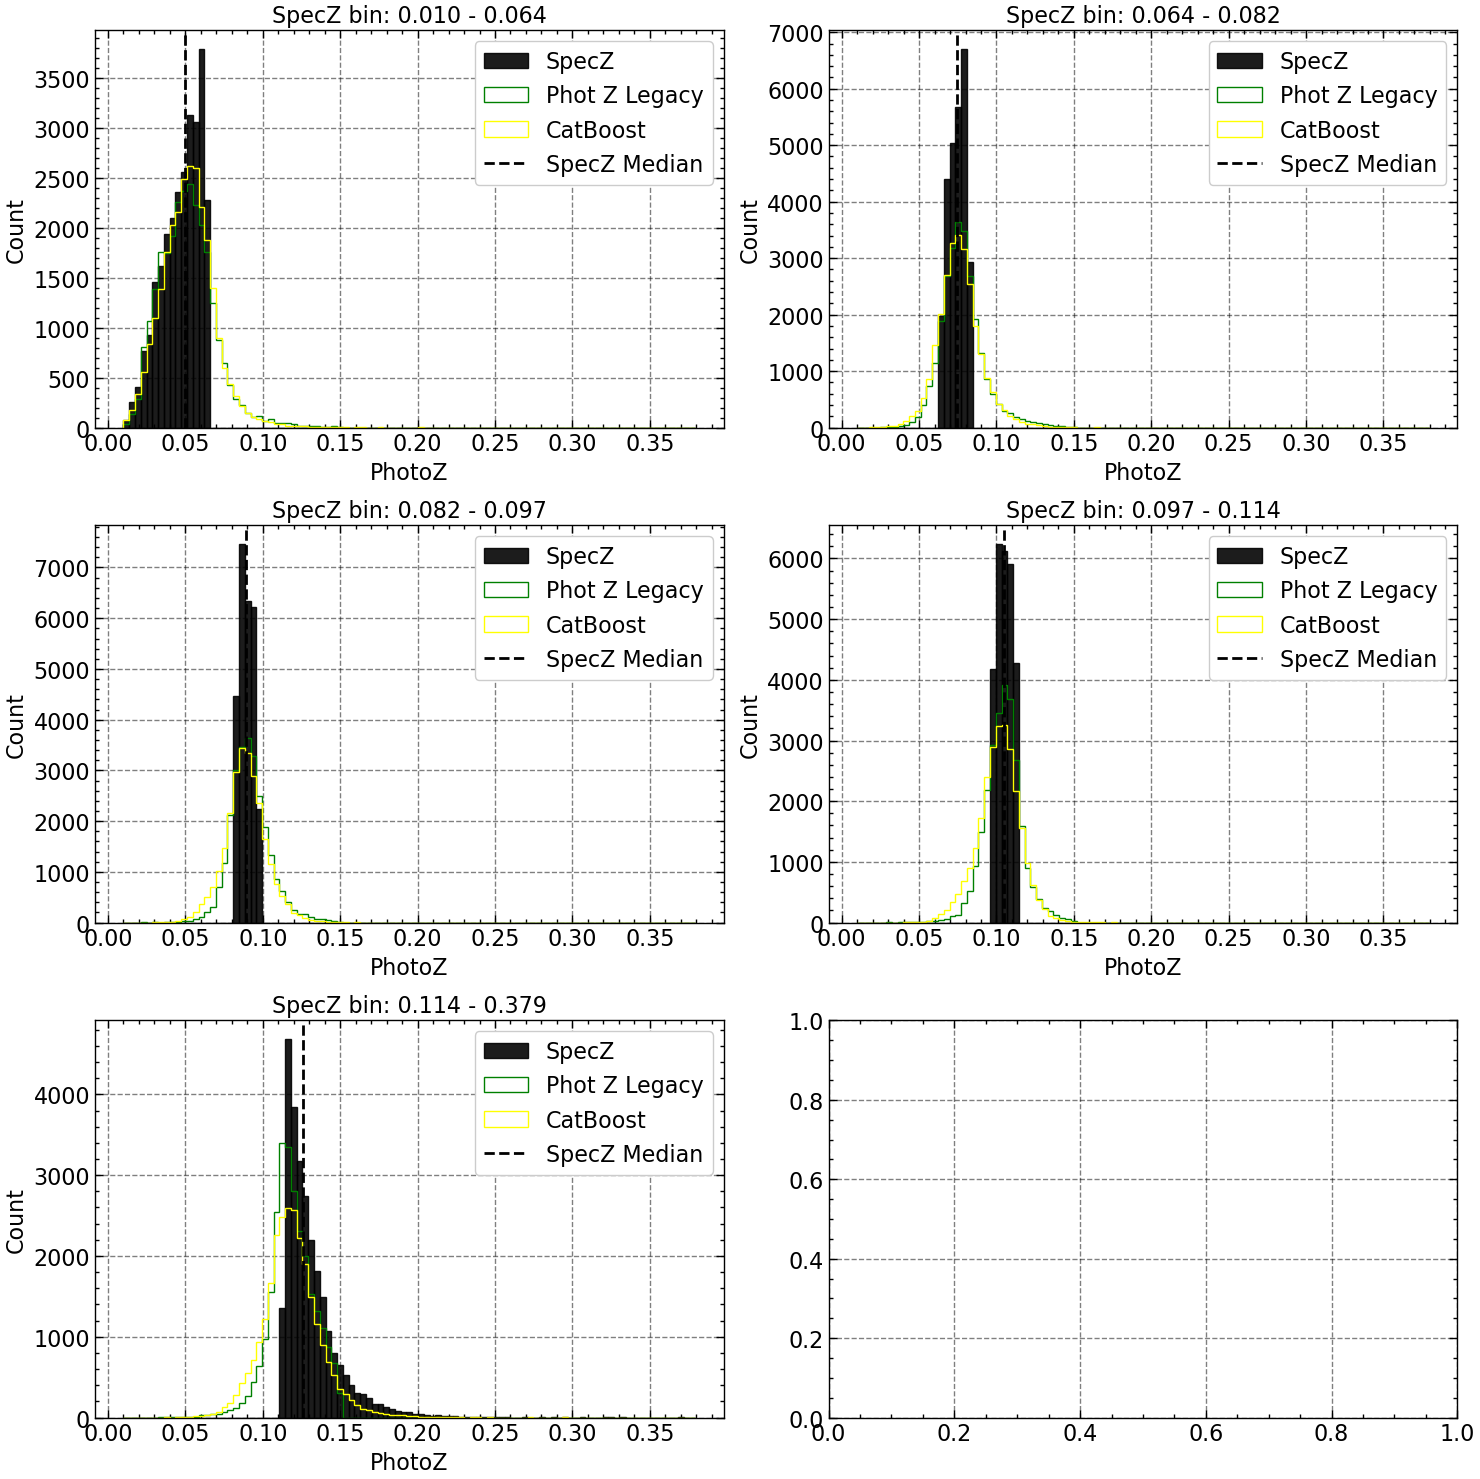

In [151]:
nbins = 5 

import pandas as pd
df = matched_dr.to_pandas()
df['bin'],bins =pd.qcut(df['Z'], q=nbins,labels=False,retbins=True,duplicates='drop')



fig,axes = plt.subplots(3,2,figsize = (15,15))
axes = axes.flatten()
for i in range(1, nbins+1):
    print(i,bins[i],bins[i-1])
    mask = np.array(df['bin']) == i-1
    phot_z_bin  = matched_FP['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = matched_dr['Z'][mask]
    bin_hist = np.linspace(bins[0],bins[-1],100)
    phot_z_bin_catboost = z_pred[mask]
    bin_hist = np.linspace(bins[0], bins[-1], 100)

    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.89, label='SpecZ',edgecolor='k',color='k')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =1, label='Phot Z Legacy',edgecolor='g',histtype='step')
    axes[i-1].hist(phot_z_bin_catboost, bins=bin_hist, alpha=1, label='CatBoost', edgecolor='yellow',histtype='step')

    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {bins[i-1]:.3f} - {bins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

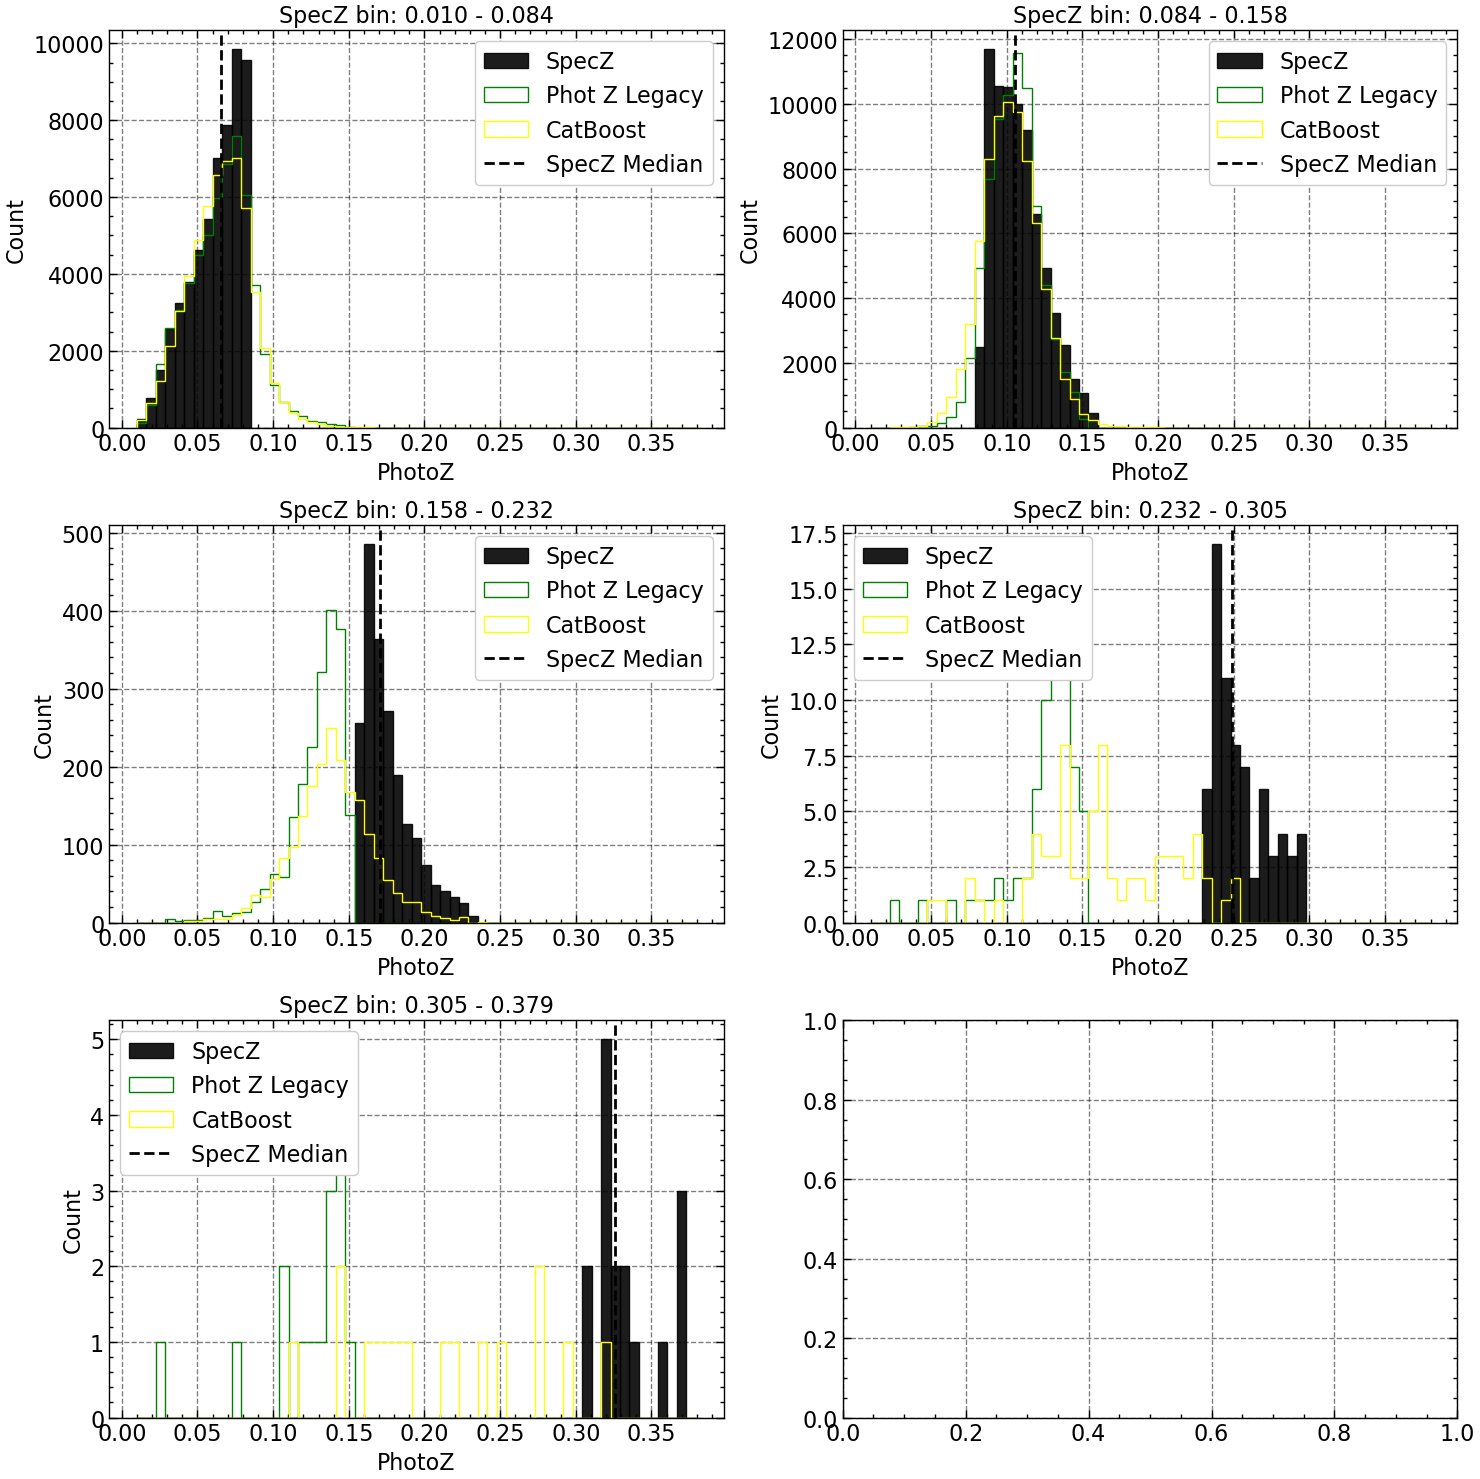

In [115]:
nbins = 5 
zbins = np.linspace(np.min(matched_dr['Z']), np.max(matched_dr['Z']), nbins+1)
bin_indices = np.digitize(matched_dr['Z'], zbins)
fig,axes = plt.subplots(3,2,figsize = (15,15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = matched_FP['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = matched_dr['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    phot_z_bin_catboost = z_pred[mask]
    bin_hist = np.linspace(zbins[0], zbins[-1], 60)

    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.89, label='SpecZ',edgecolor='k',color='k')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =1, label='Phot Z Legacy',edgecolor='g',histtype='step')
    axes[i-1].hist(phot_z_bin_catboost, bins=bin_hist, alpha=1, label='CatBoost', edgecolor='yellow',histtype='step')

    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

In [ ]:
nbins = 5 
zbins = np.linspace(np.min(matched_dr['Z']), np.max(matched_dr['Z']), nbins+1)
bin_indices = np.digitize(matched_dr['Z'], zbins)
fig,axes = plt.subplots(3,2,figsize = (15,15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = matched_FP['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = matched_dr['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')

    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='Phot Z Legacy',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

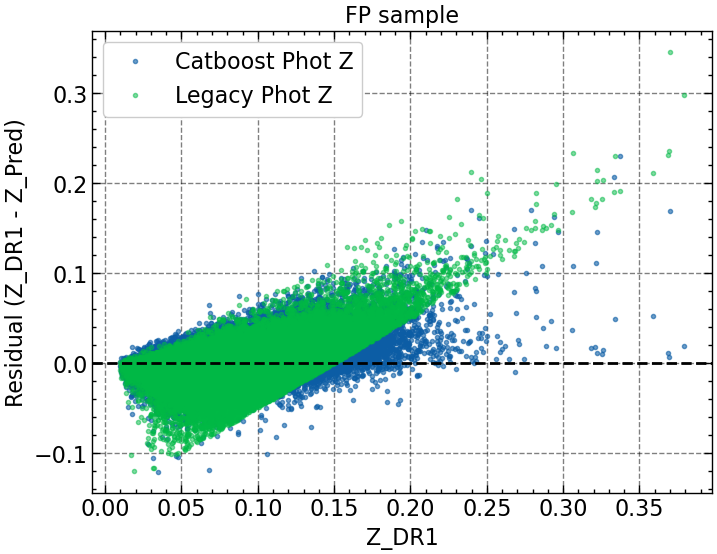

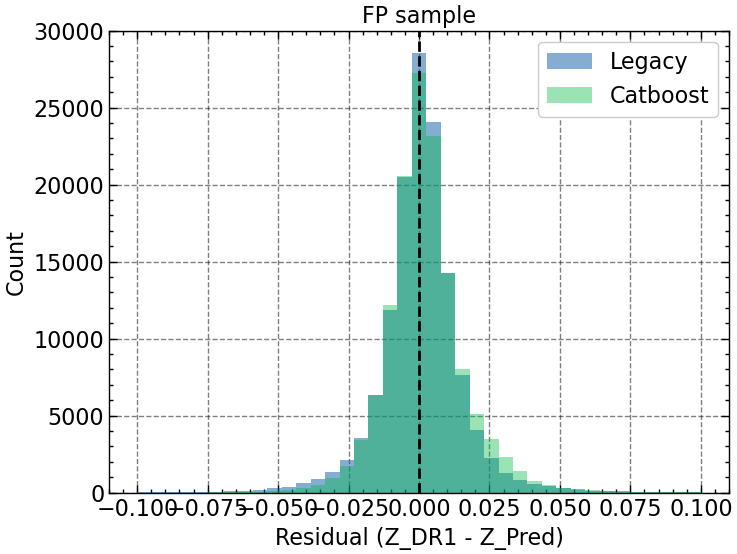

In [80]:
plt.plot(matched_dr['Z'],matched_dr['Z']-z_pred,'.',alpha=0.6,label = 'Catboost Phot Z')
plt.plot(matched_dr['Z'],matched_dr['Z']-matched_FP['Z_PHOT_MEDIAN'],'.',alpha=0.5,label = 'Legacy Phot Z')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('FP sample')
plt.legend()
plt.show()
bins = np.linspace(-0.1,0.1,40)
plt.hist(matched_dr['Z']-matched_FP['Z_PHOT_MEDIAN'], bins=bins,alpha=0.5, label='Legacy')
plt.hist(matched_dr['Z']-z_pred, bins=bins,alpha=0.4, label='Catboost')
plt.axvline(0,color='k',ls='--')
plt.xlabel('Residual (Z_DR1 - Z_Pred)')
plt.ylabel('Count')
plt.title('FP sample')
plt.legend()
plt.show()

In [32]:
from scipy.stats import gaussian_kde

def kde2d(x, y, gridsize=100):
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    X, Y = np.mgrid[xmin:xmax:gridsize*1j, ymin:ymax:gridsize*1j]
    Z = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z
X1, Y1, Z1 = kde2d(matched_FP['Z_PHOT_MEDIAN'],matched_dr['Z'])
X2, Y2, Z2 = kde2d(z_pred,matched_dr['Z'])

In [33]:
loglevels= np.logspace(np.log10(10), np.log10(500), num=10)
loglevels = np.r_[0,loglevels]
loglevels

array([  0.        ,  10.        ,  15.44452105,  23.85332304,
        36.84031499,  56.89810203,  87.87639344, 135.72088083,
       209.61440008, 323.73940143, 500.        ])

In [34]:
levels = np.linspace(0, 500, 10)

/tmp/ipykernel_1632421/2675365099.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_1632421/2675365099.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_1632421/2675365099.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Photo Z legacy')
/tmp/ipykernel_1632421/2675365099.py:6: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=levels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_1632421/2675365099.py:6: UserWar

(0.0, 0.2)

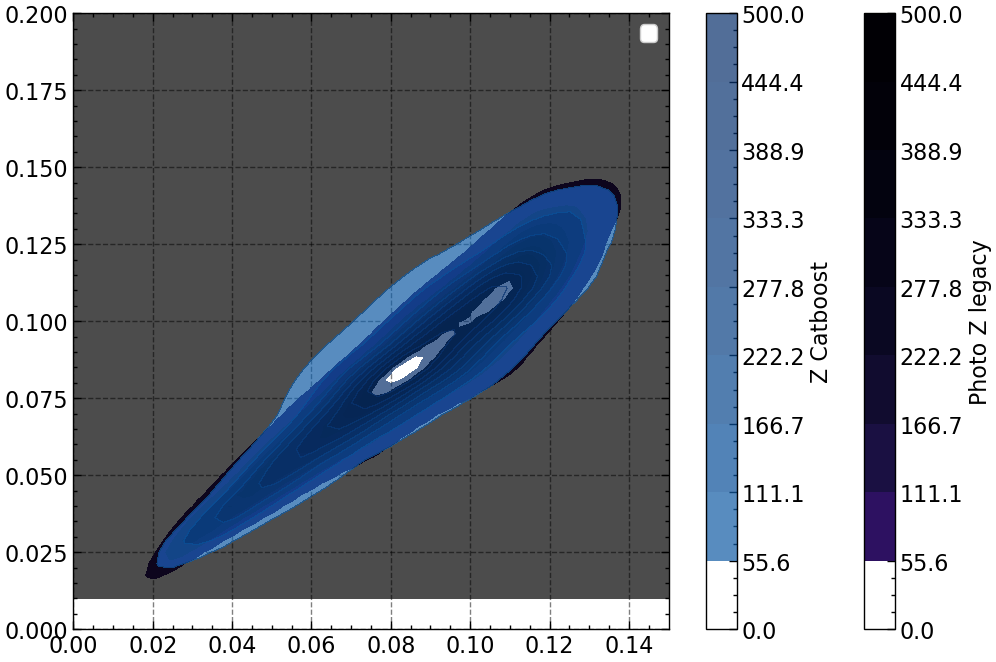

In [35]:
plt.figure(figsize=(12,8))
plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=levels, norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Photo Z legacy')


plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=levels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Z Catboost')
plt.legend()
plt.xlim(0,0.15)
plt.ylim(0,0.2)

/tmp/ipykernel_773775/1455677100.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Photo Z legacy')
/tmp/ipykernel_773775/1455677100.py:6: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
/tmp/ipykernel_773775/1455677100.py:6: UserW

(0.0, 0.2)

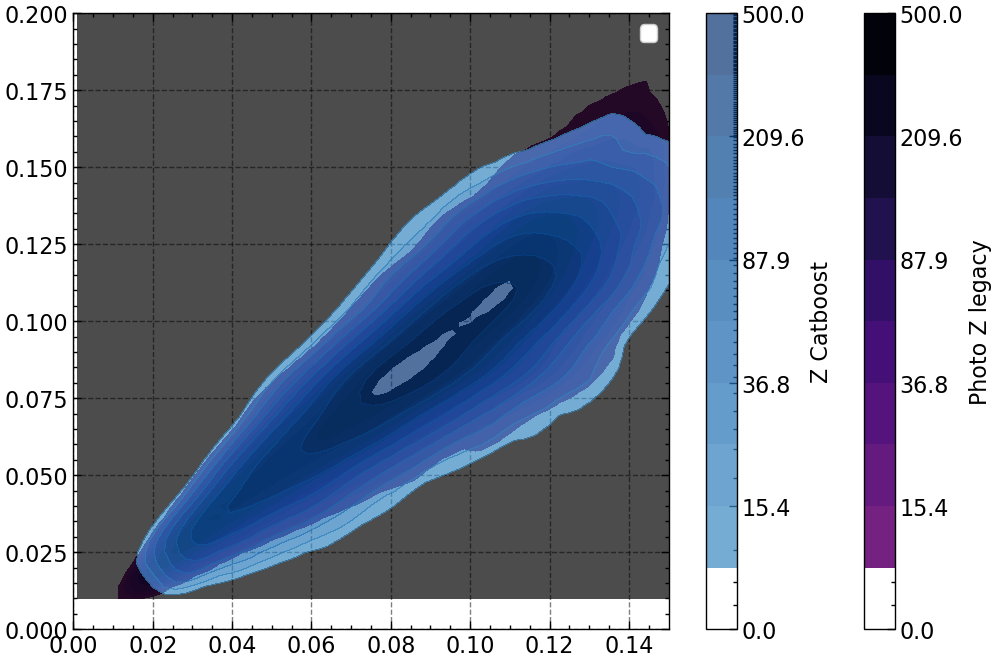

In [43]:
plt.figure(figsize=(12,8))
plt.contourf(X1, Y1, Z1, cmap='magma_r', linewidths=1.5,label='Legacy photo z ',levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Photo Z legacy')
1

plt.contourf(X2, Y2, Z2, cmap='Blues', linewidths=1.5,label='Catboost Z ',alpha=0.7,levels=loglevels,norm=LogNorm(vmin=0.01, vmax=500))
plt.colorbar(label='Z Catboost')
plt.legend()
plt.xlim(0,0.15)
plt.ylim(0,0.2)

/tmp/ipykernel_1632421/4041210135.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X2, Y2, Z2, colors='red', linewidths=1.5,label='Catboost Z ')
/tmp/ipykernel_1632421/4041210135.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, Y1, Z1, colors='blue', linewidths=1.5,label='Legacy photo z ')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


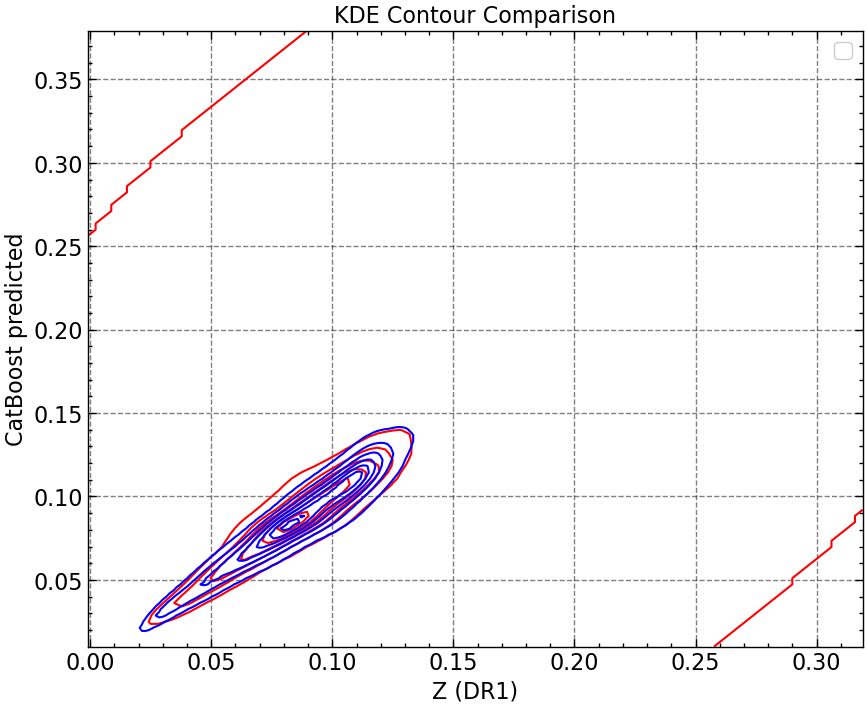

In [40]:
plt.figure(figsize=(10,8))
plt.contour(X2, Y2, Z2, colors='red', linewidths=1.5,label='Catboost Z ')
plt.contour(X1, Y1, Z1, colors='blue', linewidths=1.5,label='Legacy photo z ')

plt.xlabel('Z (DR1)')
plt.ylabel('CatBoost predicted')
plt.title('KDE Contour Comparison')
plt.legend()

/tmp/ipykernel_720524/25486365.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


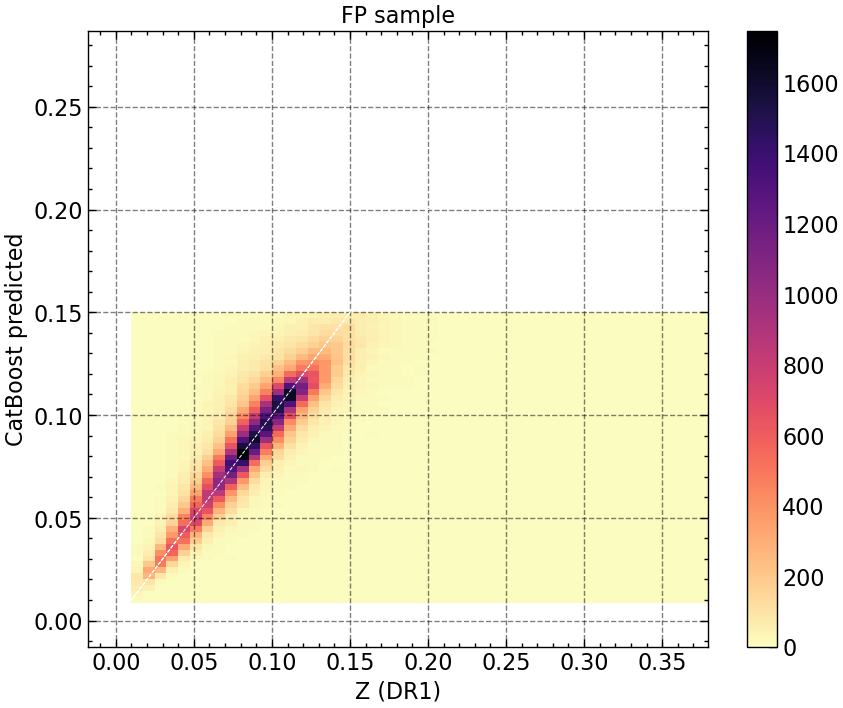

In [21]:
# Linear scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='magma_r')
plt.plot(z_pred, z_pred, 'w--', lw=0.7)
plt.colorbar()
plt.title('FP sample')

plt.xlabel('Z (DR1)')
plt.ylabel('CatBoost predicted')
#plt.xlim(0, 0.15)
#plt.ylim(0, 0.25)
plt.show()


### For the Full intersection legacy and DR1 sample

In [43]:
DR1_north= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_north_v1_sep_1.fits')[1].read())
DR1_south= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1.fits')[1].read())
DR1_full = vstack([DR1_north,DR1_south])
legacy_north = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1.fits')[1].read())
legacy_south = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1.fits')[1].read())
legacy_full = vstack([legacy_north,legacy_south])
mask1 = np.isfinite(DR1_full['Z'])
mask2  = DR1_full['Z']>0
mask3 = np.isfinite(legacy_full['Z_PHOT_MEDIAN'])
mask4 = legacy_full['Z_PHOT_MEDIAN']>0
DR1_full = DR1_full[mask1 & mask2 & mask4 &mask3]
legacy_full = legacy_full[mask1 & mask2 & mask4 &mask3]

In [44]:
legacy_full = add_colors(legacy_full)
legacy_full = _add_features( legacy_full)

In [152]:
legacy_full=add_colors(legacy_full)
#feature_names = ['MAG_GR', 'MAG_G', 'MAG_RZ', 'MAG_R', 'MAG_RW1', 'MAG_ZW1', 'MAG_W1W2']
X_full = legacy_full[feature_names].to_pandas().to_numpy()
z_pred_full=model.predict(X_full)


/tmp/ipykernel_1632421/1336510815.py:13: RuntimeWarning: overflow encountered in multiply
  MAG[i] = 22.5 - 2.5 * mag
/tmp/ipykernel_1632421/1336510815.py:13: RuntimeWarning: invalid value encountered in multiply
  MAG[i] = 22.5 - 2.5 * mag
/tmp/ipykernel_1632421/1336510815.py:14: RuntimeWarning: overflow encountered in multiply
  MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext
/tmp/ipykernel_1632421/1336510815.py:14: RuntimeWarning: invalid value encountered in multiply
  MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext


In [32]:
feature_names

['MAG_G',
 'MAG_R',
 'MAG_Z',
 'MAG_W1',
 'MAG_W2',
 'MAG_W3',
 'MAG_GR',
 'MAG_RZ',
 'MAG_GZ',
 'MAG_W1W2',
 'MAG_W2W3',
 'MAG_W1W3',
 'MAG_RW1',
 'MAG_RW2',
 'MAG_RW3',
 'MAG_GW1',
 'MAG_GW2',
 'MAG_GW3',
 'MAG_ZW1',
 'MAG_ZW2',
 'MAG_ZW3',
 'R_CIRC',
 'BBA',
 'SHAPE_E1',
 'SHAPE_E2',
 'SERSIC',
 'TYPE']

/tmp/ipykernel_1632421/1113800940.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

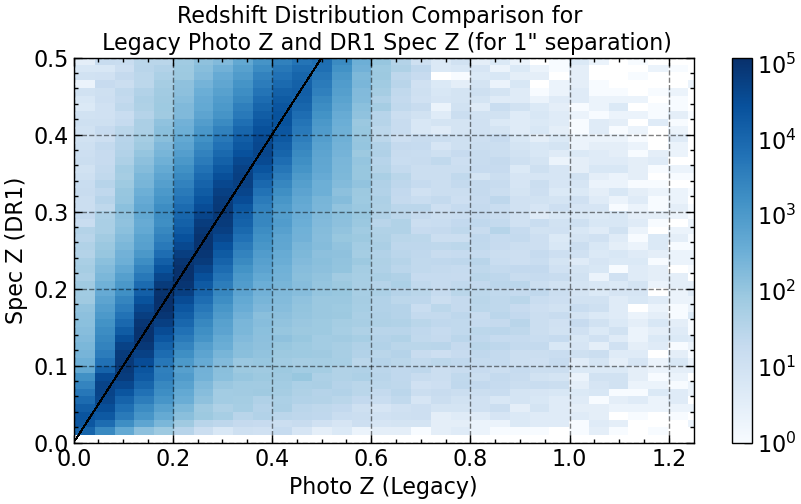

In [109]:
plt.figure(figsize=(10,5))
binx = np.linspace(min(legacy_full['Z_PHOT_MEDIAN']), max(legacy_full['Z_PHOT_MEDIAN']), 50)
biny = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
hist,xedges,yedges=np.histogram2d(legacy_full['Z_PHOT_MEDIAN'], DR1_full['Z'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues',norm=LogNorm())

plt.plot(legacy_full['Z_PHOT_MEDIAN'],legacy_full['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlim(0,1.25)
plt.ylim(0,0.5)
plt.ylabel('Spec Z (DR1)')

plt.xlabel('Photo Z (Legacy)')
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

In [117]:
metric = PhotoZMetrics(DR1_full['Z'], z_pred_full)
print('MSE for Catboost :',mean_squared_error(DR1_full['Z'], z_pred_full))
print('MAE for Catboost :',mean_absolute_error(DR1_full['Z'], z_pred_full))
print('R2 for Catboost :',r2_score(DR1_full['Z'], z_pred_full))
print('Photo Z metrics')
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.0011651494673408154
MAE for Catboost : 0.02360364623067118
R2 for Catboost : 0.8985442366227869
Photo Z metrics
bias for Catboost: -0.0004752274567132827
sigma for Catboost: 0.027584328374024174
sigma_NMAD for Catboost: 0.019831398379140133
delta(0.3) for Catboost: 0.9999651837997946
outlier_fraction(0.15) for Catboost: 0.0017084431909834788
------------------------------------------------------------
MSE for Legacy : 0.0021560623889930078
MAE for Legacy : 0.02634908468845017
R2 for Legacy : 0.8122601763159039
Photo Z metrics
bias for Legacy: -0.0013821556202648162
sigma for Legacy: 0.03799489891928678
sigma_NMAD for Legacy: 0.0198782264768596
delta(0.3) for Legacy: 0.9981634891781103
outlier_fraction(0.15) for Legacy: 0.005792785873370505


In [82]:
metric = PhotoZMetrics(DR1_full['Z'], z_pred_full)
print('MSE for Catboost :',mean_squared_error(DR1_full['Z'], z_pred_full))
print('MAE for Catboost :',mean_absolute_error(DR1_full['Z'], z_pred_full))
print('R2 for Catboost :',r2_score(DR1_full['Z'], z_pred_full))
print('Photo Z metrics')
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(DR1_full['Z'], legacy_full['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.017601418400344824
MAE for Catboost : 0.10197012347420878
R2 for Catboost : -0.5326491496445553
Photo Z metrics
bias for Catboost: 0.08810746557074803
sigma for Catboost: 0.07409172349660482
sigma_NMAD for Catboost: 0.09703816643205836
delta(0.3) for Catboost: 0.9999991252211003
outlier_fraction(0.15) for Catboost: 0.1528116268613108
------------------------------------------------------------
MSE for Legacy : 0.0021560623889930078
MAE for Legacy : 0.02634908468845017
R2 for Legacy : 0.8122601763159039
Photo Z metrics
bias for Legacy: -0.0013821556202648162
sigma for Legacy: 0.03799489891928678
sigma_NMAD for Legacy: 0.0198782264768596
delta(0.3) for Legacy: 0.9981634891781103
outlier_fraction(0.15) for Legacy: 0.005792785873370505


(array([  5141.,  42784.,  77556., 101799., 140333., 187188., 181031.,
        211242., 246701., 258229., 268779., 285164., 293485., 301647.,
        300305., 291110., 276608., 275358., 258591., 231294., 212802.,
        195797., 183825., 164655., 145641., 127978., 108376.,  92422.,
         77272.,  63600.,  49291.,  38732.,  20994.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.]),
 array([0.        , 0.01530612, 0.03061224, 0.04591837, 0.06122449,
        0.07653061, 0.09183673, 0.10714286, 0.12244898, 0.1377551 ,
        0.15306122, 0.16836735, 0.18367347, 0.19897959, 0.21428571,
        0.22959184, 0.24489796, 0.26020408, 0.2755102 , 0.29081633,
        0.30612245, 0.32142857, 0.33673469, 0.35204082, 0.36734694,
        0.38265306, 0.39795918, 0.41326531, 0.42857143, 0.44387755,
        0.45918367, 0.4744898 , 0.48979592, 0.50510204, 0.52040816,
        0.53571429, 0.551

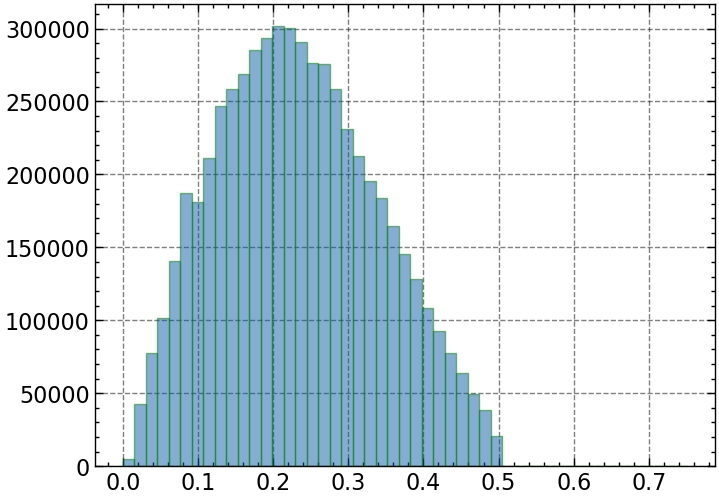

In [28]:
plt.hist(DR1_full['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')

In [3]:

import numpy as np
from itertools import product
values = np.linspace(0, 10, 10)
for x, y in product(values, repeat=2):
        print(np.array([x, y]))

[0. 0.]
[0.         1.11111111]
[0.         2.22222222]
[0.         3.33333333]
[0.         4.44444444]
[0.         5.55555556]
[0.         6.66666667]
[0.         7.77777778]
[0.         8.88888889]
[ 0. 10.]
[1.11111111 0.        ]
[1.11111111 1.11111111]
[1.11111111 2.22222222]
[1.11111111 3.33333333]
[1.11111111 4.44444444]
[1.11111111 5.55555556]
[1.11111111 6.66666667]
[1.11111111 7.77777778]
[1.11111111 8.88888889]
[ 1.11111111 10.        ]
[2.22222222 0.        ]
[2.22222222 1.11111111]
[2.22222222 2.22222222]
[2.22222222 3.33333333]
[2.22222222 4.44444444]
[2.22222222 5.55555556]
[2.22222222 6.66666667]
[2.22222222 7.77777778]
[2.22222222 8.88888889]
[ 2.22222222 10.        ]
[3.33333333 0.        ]
[3.33333333 1.11111111]
[3.33333333 2.22222222]
[3.33333333 3.33333333]
[3.33333333 4.44444444]
[3.33333333 5.55555556]
[3.33333333 6.66666667]
[3.33333333 7.77777778]
[3.33333333 8.88888889]
[ 3.33333333 10.        ]
[4.44444444 0.        ]
[4.44444444 1.11111111]
[4.44444444 2.22

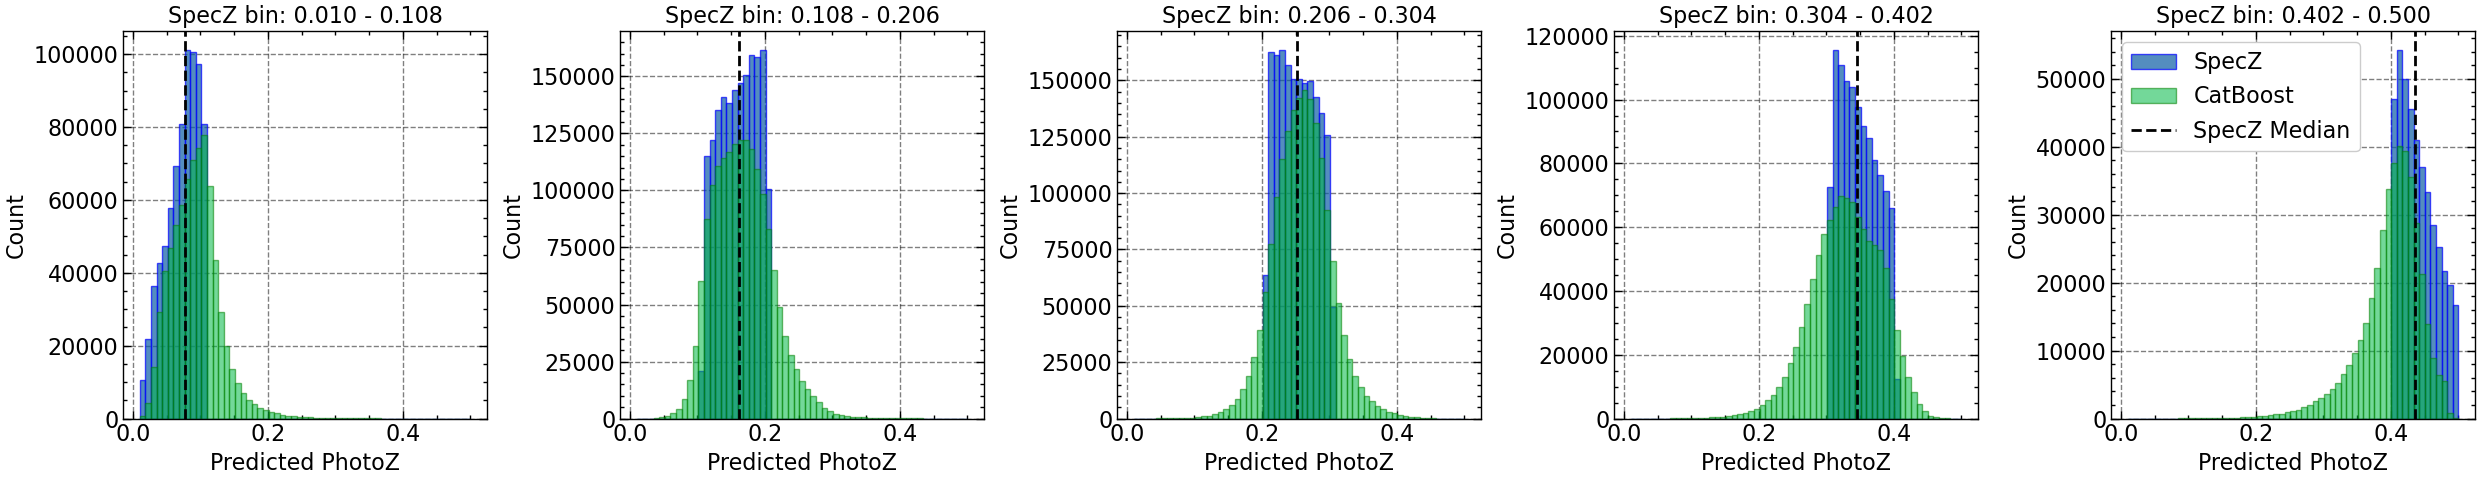

In [ ]:
nbins = 5 
zbins = np.linspace(np.min(DR1_full['Z']), np.max(DR1_full['Z']), nbins+1)
bin_indices = np.digitize(DR1_full['Z'], zbins)
fig,axes = plt.subplots(1,5,figsize = (25,5))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = z_pred_full[mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='CatBoost',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    #axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.legend()
plt.tight_layout()
plt.show()

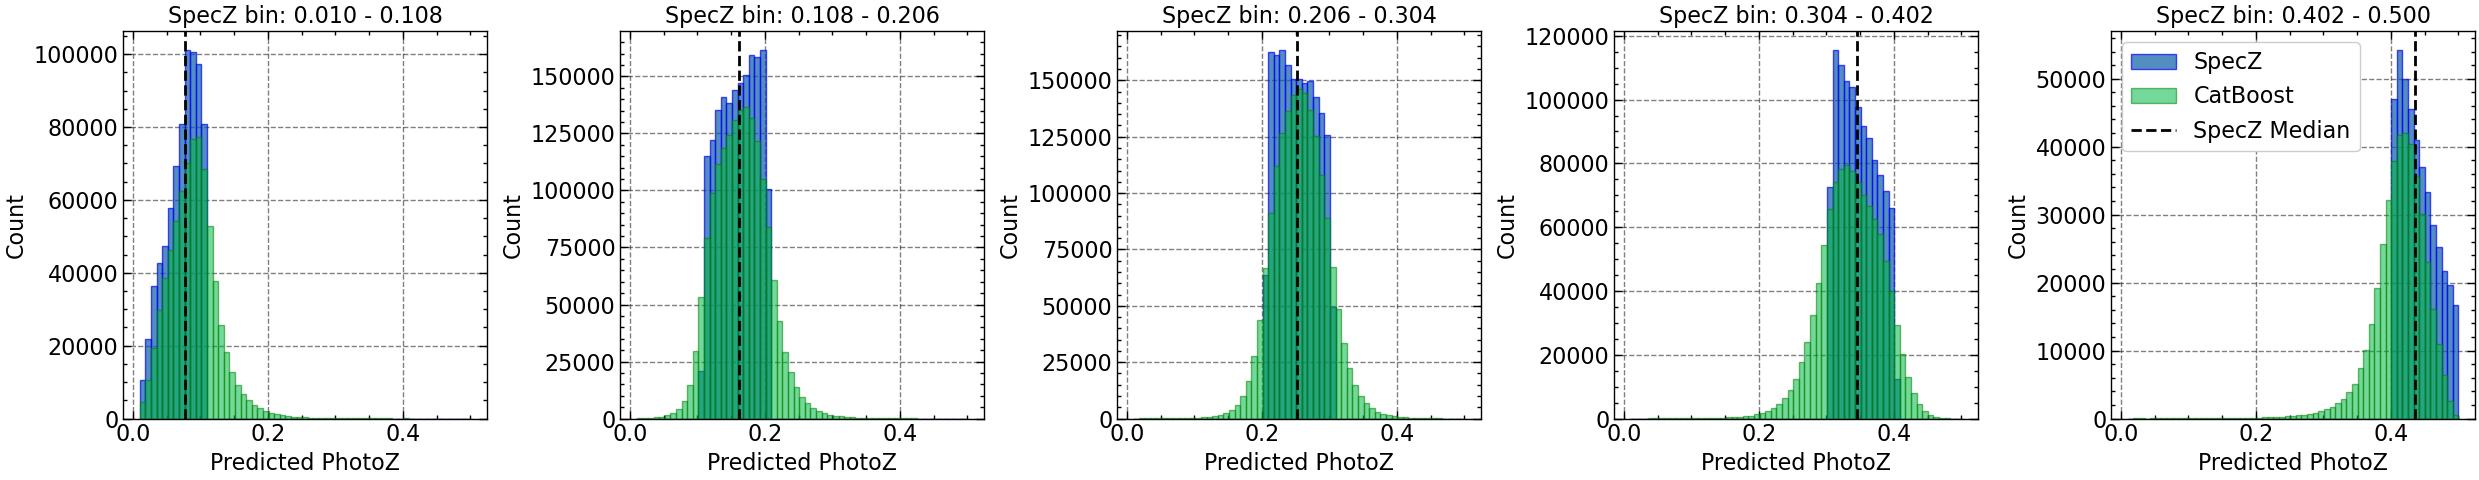

In [29]:
nbins = 5 
zbins = np.linspace(np.min(DR1_full['Z']), np.max(DR1_full['Z']), nbins+1)
bin_indices = np.digitize(DR1_full['Z'], zbins)
fig,axes = plt.subplots(1,5,figsize = (25,5))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = z_pred_full[mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='CatBoost',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    #axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.legend()
plt.tight_layout()
plt.show()

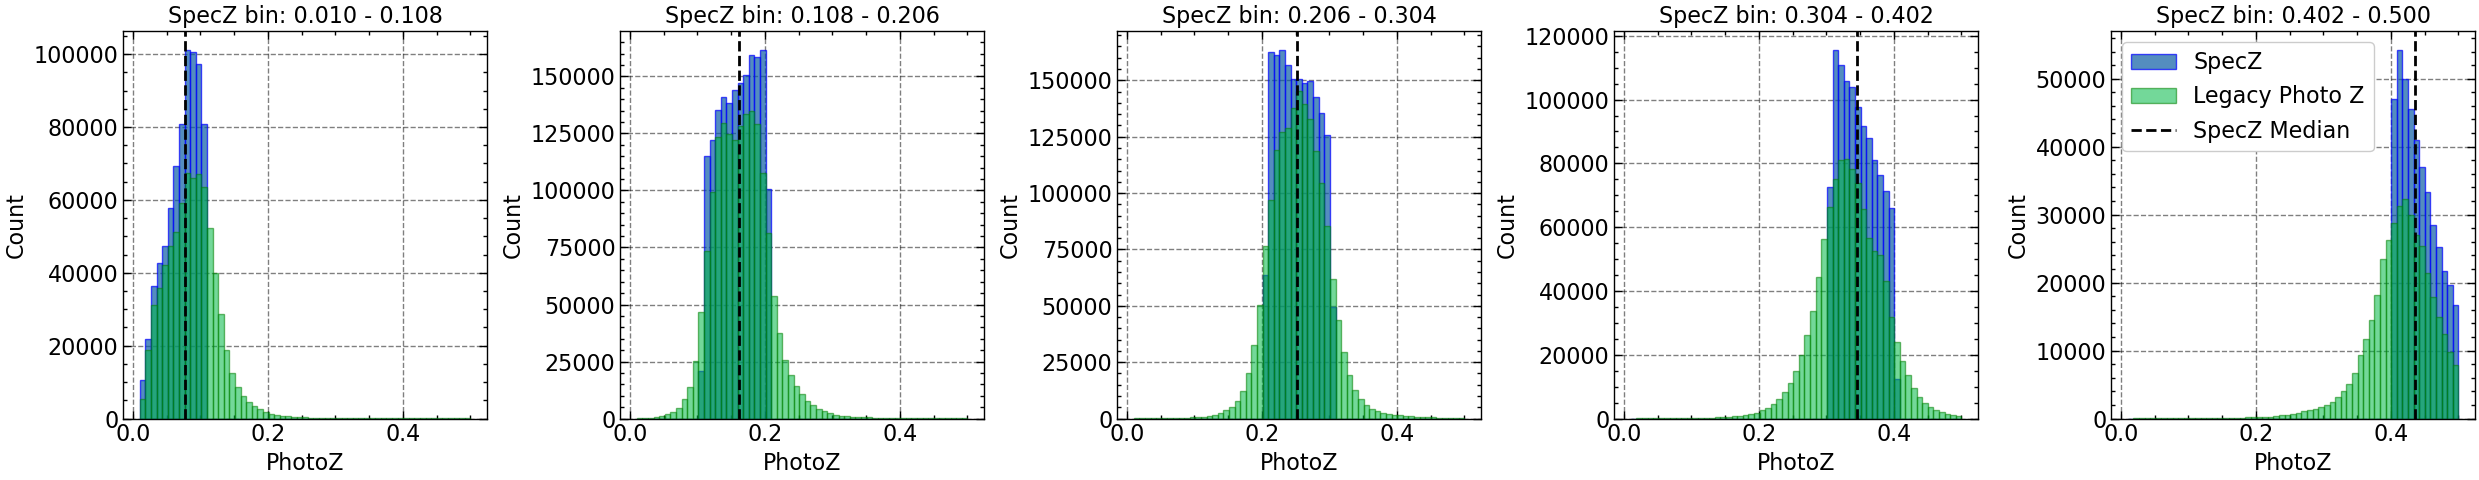

In [49]:
nbins = 5 
zbins = np.linspace(np.min(DR1_full['Z']), np.max(DR1_full['Z']), nbins+1)
bin_indices = np.digitize(DR1_full['Z'], zbins)
fig,axes = plt.subplots(1,5,figsize = (25,5))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = legacy_full['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='Legacy Photo Z',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    #axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
nbins = 5 
zbins = np.linspace(np.min(DR1_full['Z']), np.max(DR1_full['Z']), nbins+1)
bin_indices = np.digitize(DR1_full['Z'], zbins)
fig,axes = plt.subplots(1,5,figsize = (25,5))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = z_pred_full[mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.7, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.55, label='CatBoost',edgecolor='green')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

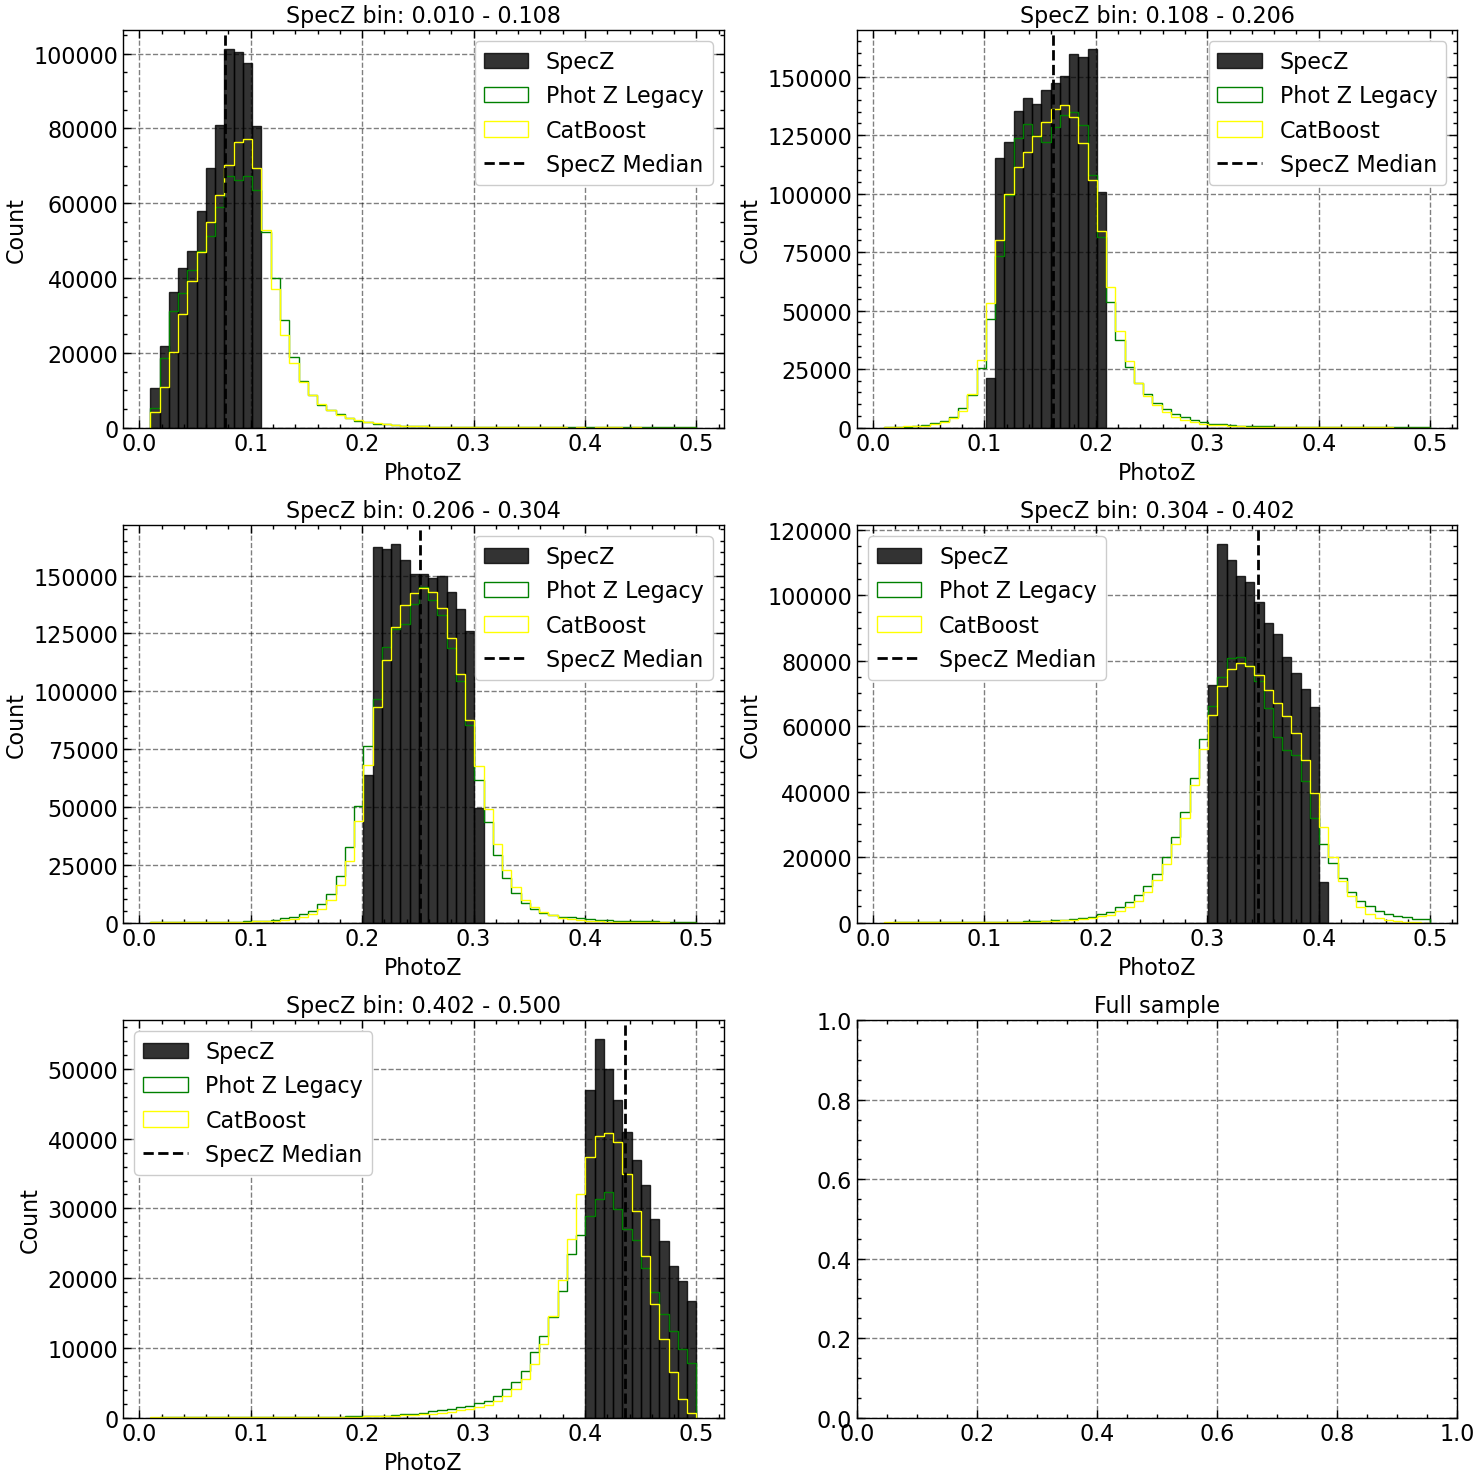

In [153]:
nbins = 5 
zbins = np.linspace(np.min(DR1_full['Z']), np.max(DR1_full['Z']), nbins+1)
bin_indices = np.digitize(DR1_full['Z'], zbins)
fig,axes = plt.subplots(3,2,figsize = (15,15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  = legacy_full['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    phot_z_bin_catboost = z_pred_full[mask]
    bin_hist = np.linspace(zbins[0], zbins[-1], 60)

    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.80, label='SpecZ',edgecolor='k',color='k')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =1, label='Phot Z Legacy',edgecolor='g',histtype='step')
    axes[i-1].hist(phot_z_bin_catboost, bins=bin_hist, alpha=1, label='CatBoost', edgecolor='yellow',histtype='step')

    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')  
plt.title('Full sample')
 
plt.tight_layout()
plt.show()

1 0.13476166304805456 0.01000122032732104
2 0.1982903621229498 0.13476166304805456
3 0.2579941740840797 0.1982903621229498
4 0.3311052107448235 0.2579941740840797
5 0.4999987434636972 0.3311052107448235


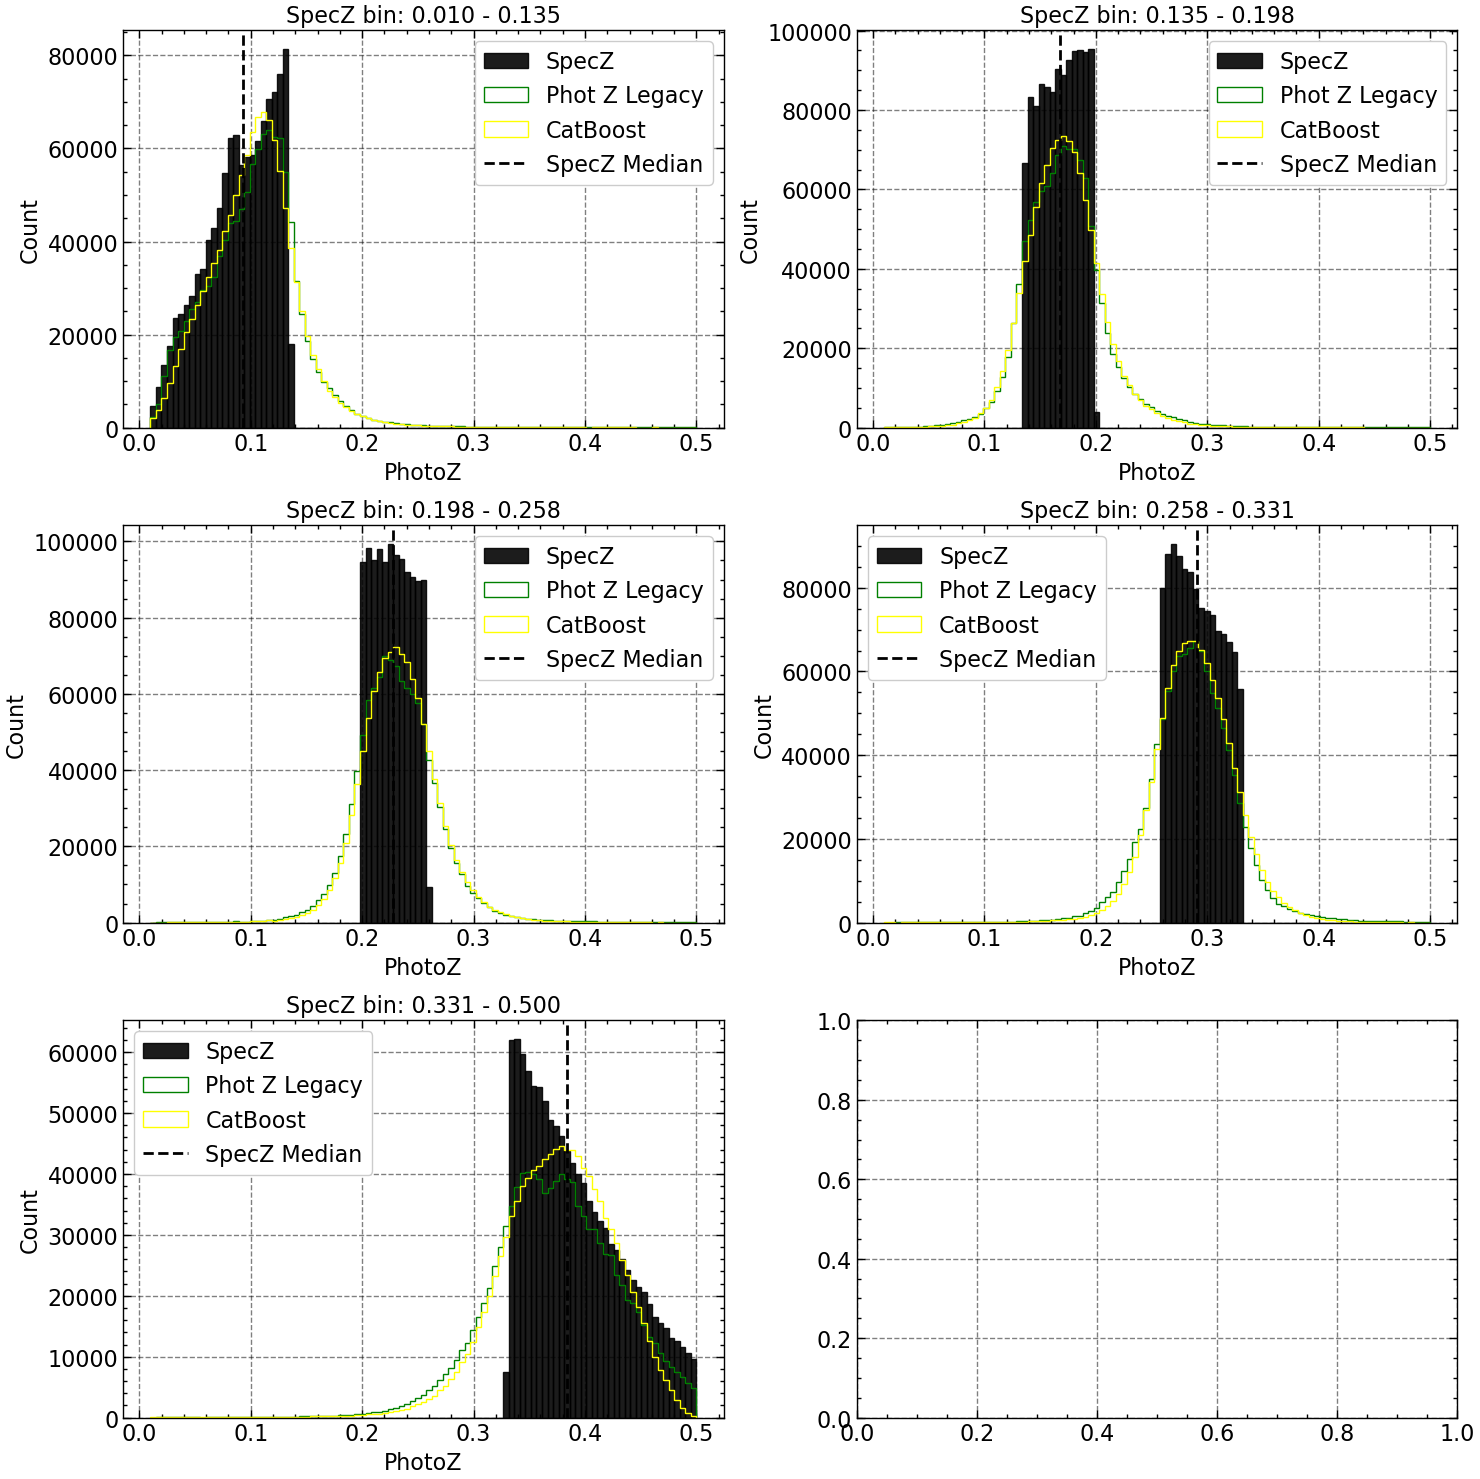

In [154]:
nbins = 5 

import pandas as pd
df = DR1_full.to_pandas()
df['bin'],bins =pd.qcut(df['Z'], q=nbins,labels=False,retbins=True,duplicates='drop')



fig,axes = plt.subplots(3,2,figsize = (15,15))
axes = axes.flatten()
for i in range(1, nbins+1):
    print(i,bins[i],bins[i-1])
    mask = np.array(df['bin']) == i-1
    phot_z_bin  = legacy_full['Z_PHOT_MEDIAN'][mask]
    spec_z_bin = DR1_full['Z'][mask]
    bin_hist = np.linspace(bins[0],bins[-1],100)
    phot_z_bin_catboost = z_pred_full[mask]
    bin_hist = np.linspace(bins[0], bins[-1], 100)

    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.89, label='SpecZ',edgecolor='k',color='k')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =1, label='Phot Z Legacy',edgecolor='g',histtype='step')
    axes[i-1].hist(phot_z_bin_catboost, bins=bin_hist, alpha=1, label='CatBoost', edgecolor='yellow',histtype='step')

    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {bins[i-1]:.3f} - {bins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

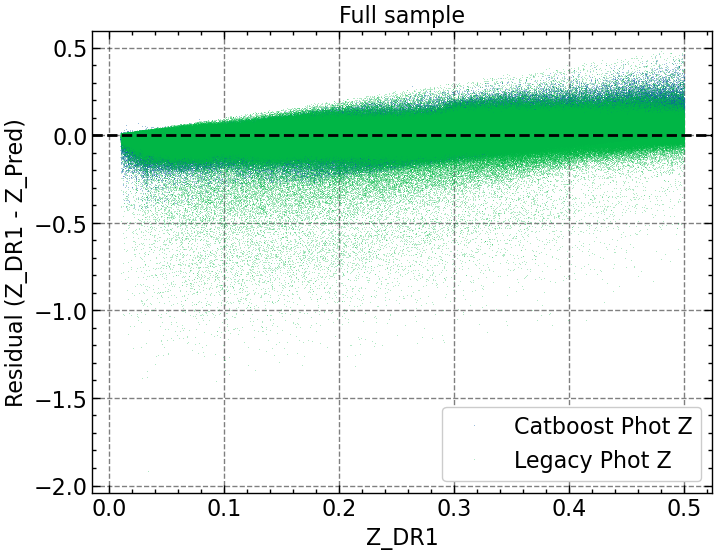

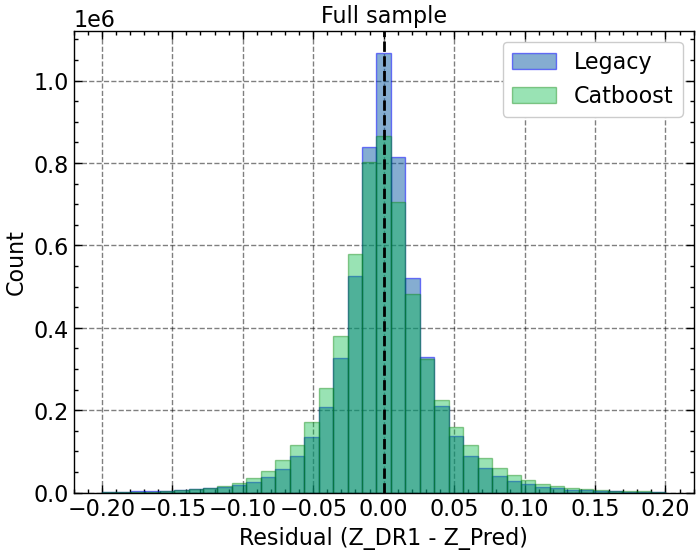

In [59]:
plt.plot(DR1_full['Z'], DR1_full['Z'] - z_pred_full, ',', alpha=0.4, label='Catboost Phot Z')
plt.plot(DR1_full['Z'], DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN'], ',', alpha=0.3, label='Legacy Phot Z')
plt.axhline(0, color='k', ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('Full sample')
plt.legend()
plt.show()

bins = np.linspace(-0.2, 0.2, 40)
plt.hist(DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN'], bins=bins, alpha=0.5, label='Legacy', edgecolor='blue')
plt.hist(DR1_full['Z'] - z_pred_full, bins=bins, alpha=0.4, label='Catboost', edgecolor='g')
plt.axvline(0, color='k', ls='--')
plt.xlabel('Residual (Z_DR1 - Z_Pred)')
plt.ylabel('Count')
plt.title('Full sample')
plt.legend()
plt.show()

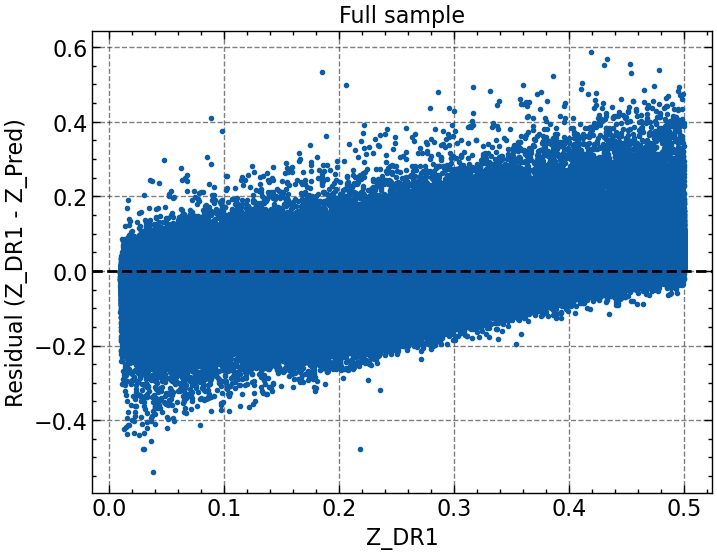

/tmp/ipykernel_1297816/1528713378.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()
/tmp/ipykernel_1297816/1528713378.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, "DR1_full['Z']-z_pred_full")

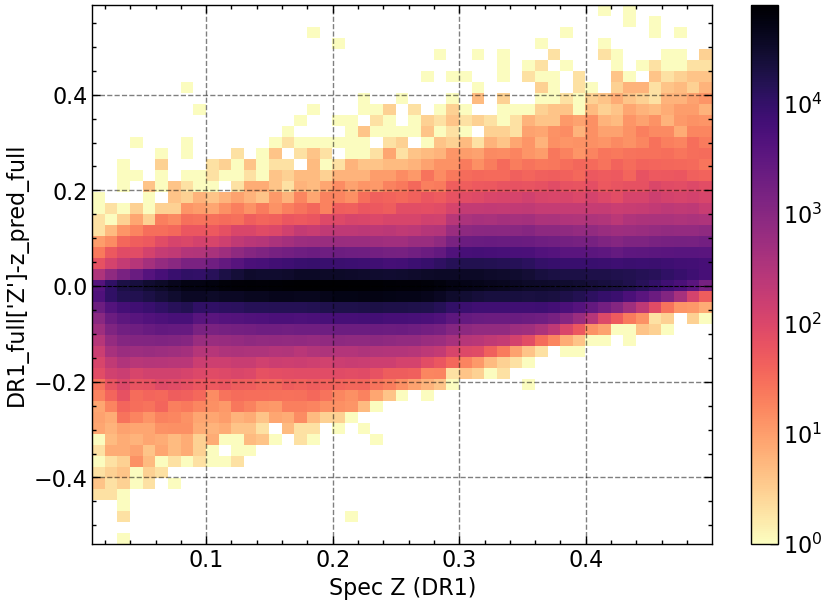

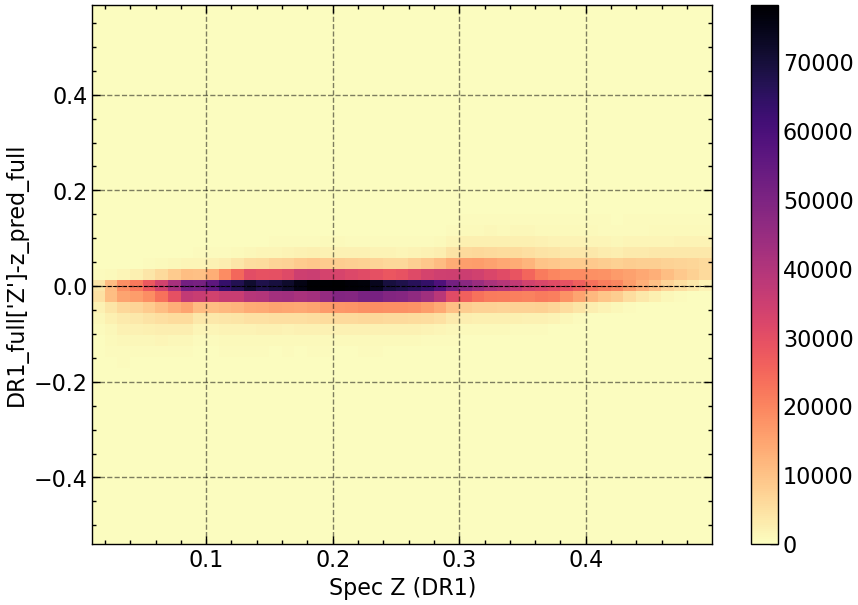

In [30]:
plt.plot(DR1_full['Z'],DR1_full['Z']-z_pred_full,'.')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('Full sample')
plt.show()

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z']-z_pred_full), max(DR1_full['Z']-z_pred_full), 50)
hist,xedges,yedges=np.histogram2d(DR1_full['Z'], DR1_full['Z']-z_pred_full, bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm())

plt.axhline(0,color='k',ls='--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('DR1_full[\'Z\']-z_pred_full')

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z']-z_pred_full), max(DR1_full['Z']-z_pred_full), 50)
hist,xedges,yedges=np.histogram2d(DR1_full['Z'], DR1_full['Z']-z_pred_full, bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r')

plt.axhline(0,color='k',ls='--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('DR1_full[\'Z\']-z_pred_full')

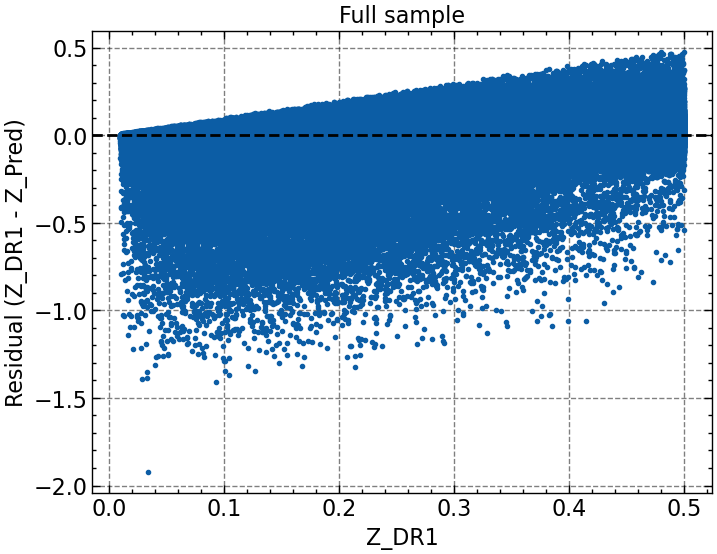

/tmp/ipykernel_804593/1355501517.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()
/tmp/ipykernel_804593/1355501517.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, "DR1_full['Z']-legacy_full['Z_PHOT_MEDIAN']")

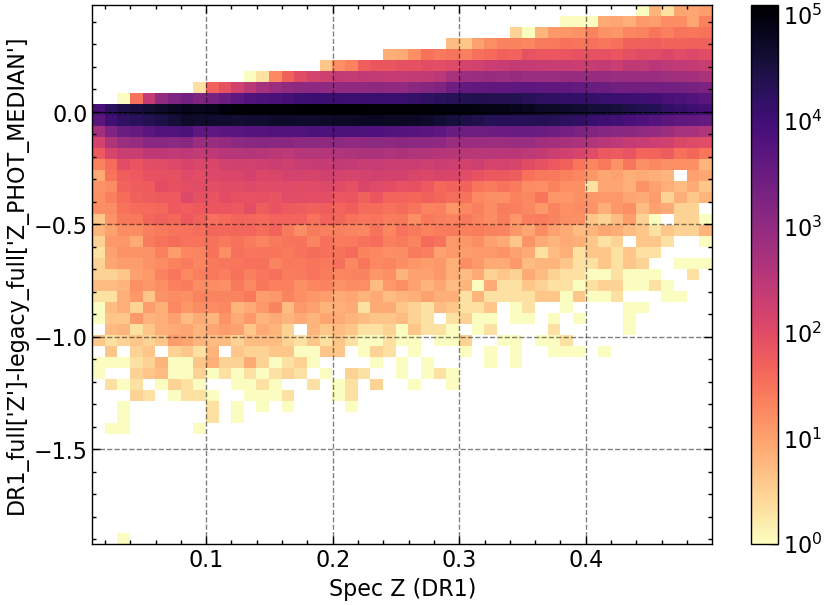

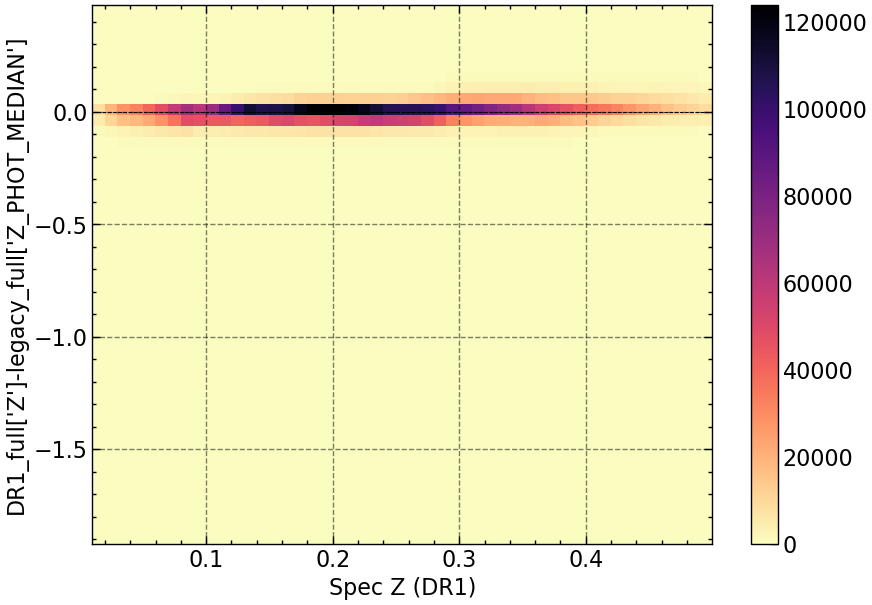

In [60]:
plt.plot(DR1_full['Z'], DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN'], '.')
plt.axhline(0, color='k', ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_PHotMedain)')
plt.title('Full sample')
plt.show()

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN']), max(DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN']), 50)
hist, xedges, yedges = np.histogram2d(DR1_full['Z'], DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto', cmap='magma_r', norm=LogNorm())

plt.axhline(0, color='k', ls='--', lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel("DR1_full['Z']-legacy_full['Z_PHOT_MEDIAN']")

plt.figure(figsize=(10,7))
binx = np.linspace(min(DR1_full['Z']), max(DR1_full['Z']), 50)
biny = np.linspace(min(DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN']), max(DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN']), 50)
hist, xedges, yedges = np.histogram2d(DR1_full['Z'], DR1_full['Z'] - legacy_full['Z_PHOT_MEDIAN'], bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto', cmap='magma_r')

plt.axhline(0, color='k', ls='--', lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel("DR1_full['Z']-legacy_full['Z_PHOT_MEDIAN']")

In [ ]:
plt.plot(matched_dr['Z'],matched_dr['Z']-z_pred,'.')
plt.axhline(0,color='k',ls='--')
plt.xlabel('Z_DR1')
plt.ylabel('Residual (Z_DR1 - Z_Pred)')
plt.title('FP sample')

Text(0.5, 1.0, 'Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

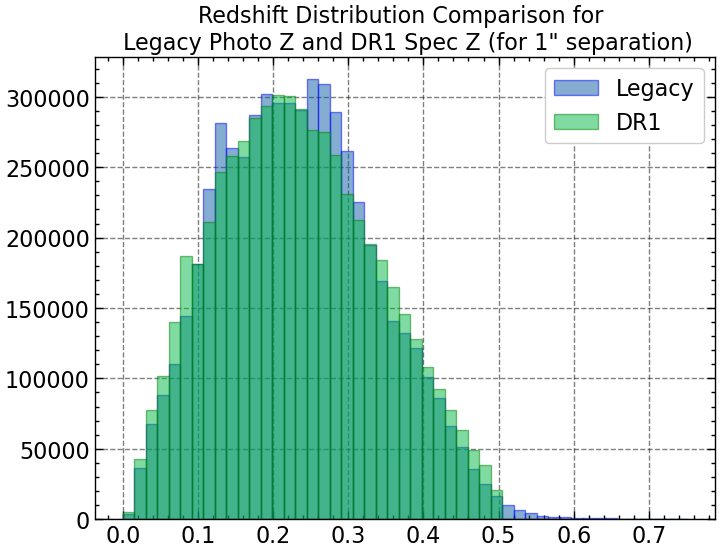

In [31]:
bins = np.linspace(0,0.75,50)
plt.hist(legacy_full['Z_PHOT_MEDIAN'], bins=bins, alpha=0.5, label='Legacy',edgecolor='blue')  
plt.hist(DR1_full['Z'], bins=bins, alpha=0.5, label='DR1',edgecolor='green')
plt.legend()
plt.title('Redshift Distribution Comparison for \n Legacy Photo Z and DR1 Spec Z (for 1" separation)')

In [59]:
def filter_data(legacy, DR1):
        """Apply quality cuts and filtering to the data"""
        print("Applying data quality cuts...")
        
        # Flux detection cuts
        mask1 = (legacy['FLUX_G'] != 0) & (legacy['FLUX_R'] != 0) & (legacy['FLUX_Z'] != 0)
        
        # Finite value cuts
        numeric_cols = [c for c in legacy.colnames if np.issubdtype(legacy[c].dtype, np.number)]
        data = np.vstack([legacy[c] for c in numeric_cols]).T
        mask2 = np.isfinite(data).all(axis=1)
        
        # Valid redshift cuts - FIXED: added upper limit
        mask3 = np.isfinite(DR1['Z']) & (DR1['Z'] > 0)
        
        combined_mask = mask1 & mask2 & mask3
        print(f"Filtered from {len(legacy)} to {np.sum(combined_mask)} objects")
        
        DR1_final=DR1[combined_mask]
        _,indeces=np.unique(DR1_final['TARGETID'],return_index=True)
        DR1_final=unique(DR1_final,keys='TARGETID')

        legacy_final=legacy[combined_mask][indeces]
        print(f"Filtered from {len(legacy)} to {len(legacy_final)} objects for unique TARGETID")

        return legacy_final, DR1_final

In [60]:
legacy_full = compute_magnitudes(legacy_full)


Computing magnitudes and colors...


In [61]:
legacy_full_filtered, DR1_full_filtered = filter_data( legacy_full, DR1_full)
matched_FP_filtered, matched_dr_filtered = filter_data( matched_FP, matched_dr)

Applying data quality cuts...
Filtered from 5715730 to 4444133 objects
Filtered from 5715730 to 4315026 objects for unique TARGETID
Applying data quality cuts...
Filtered from 133625 to 114392 objects
Filtered from 133625 to 111462 objects for unique TARGETID


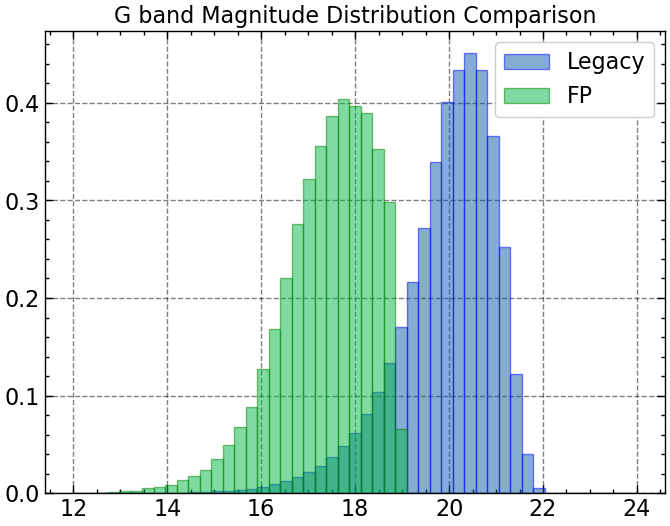

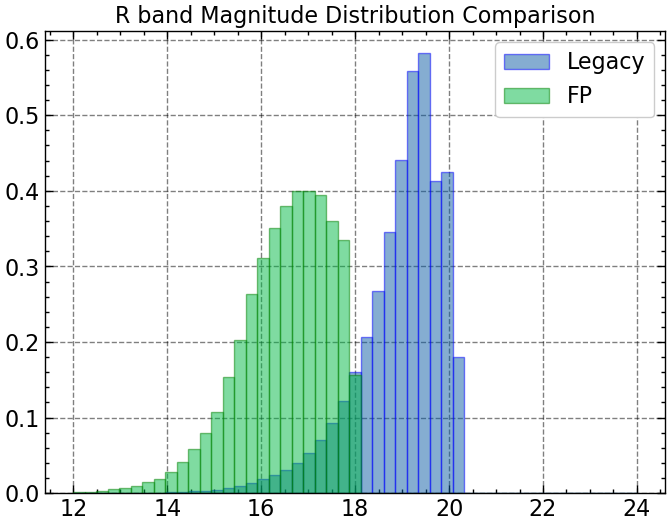

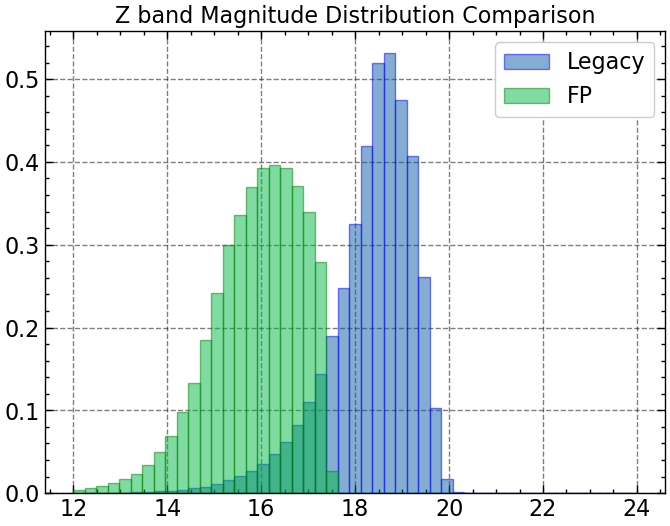

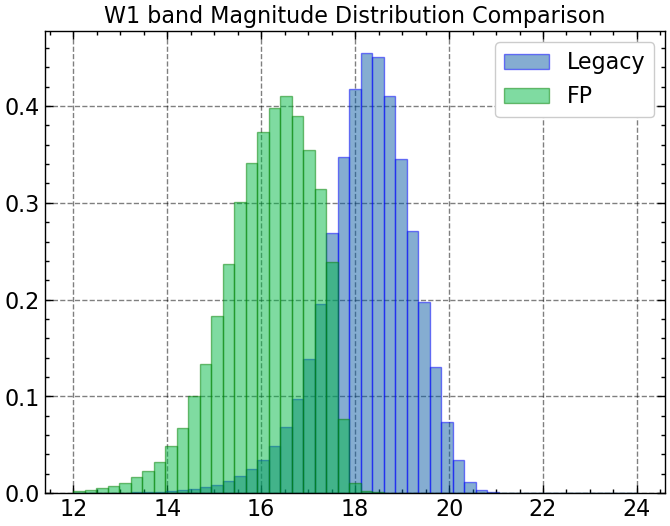

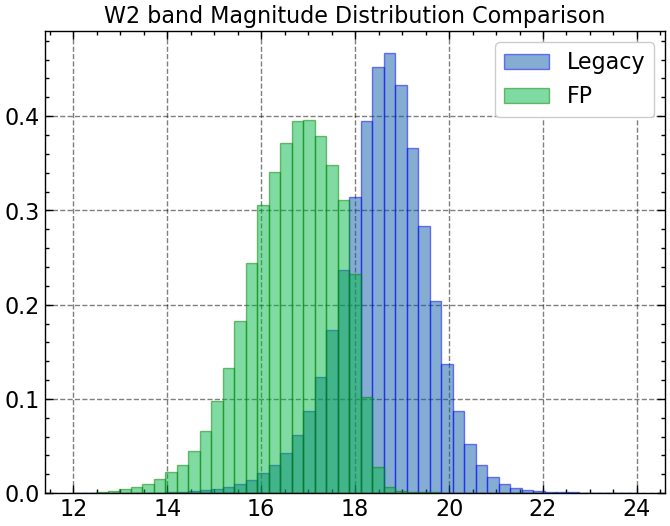

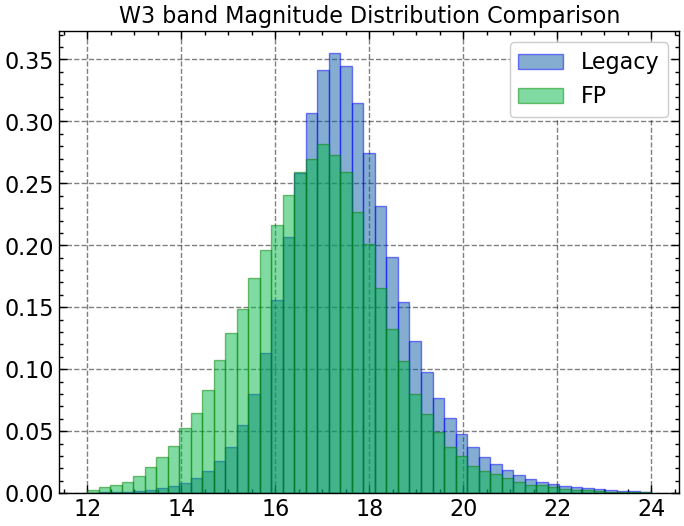

In [62]:
bins = np.linspace(12,24,50)
plt.hist(legacy_full_filtered['MAG_G'],bins =bins ,alpha=0.5,label='Legacy',edgecolor='blue',density=True)
plt.hist(matched_FP_filtered['MAG_G'],bins =bins ,alpha=0.5,label='FP',edgecolor='green',density=True)
plt.title('G band Magnitude Distribution Comparison')
plt.legend()
plt.show()

for band in ['R', 'Z', 'W1', 'W2', 'W3']:
    plt.figure()
    plt.hist(legacy_full_filtered[f'MAG_{band}'], bins=bins, alpha=0.5, label='Legacy', edgecolor='blue', density=True)
    plt.hist(matched_FP_filtered[f'MAG_{band}'], bins=bins, alpha=0.5, label='FP', edgecolor='green', density=True)
    plt.title(f'{band} band Magnitude Distribution Comparison')
    plt.legend()
    plt.show()


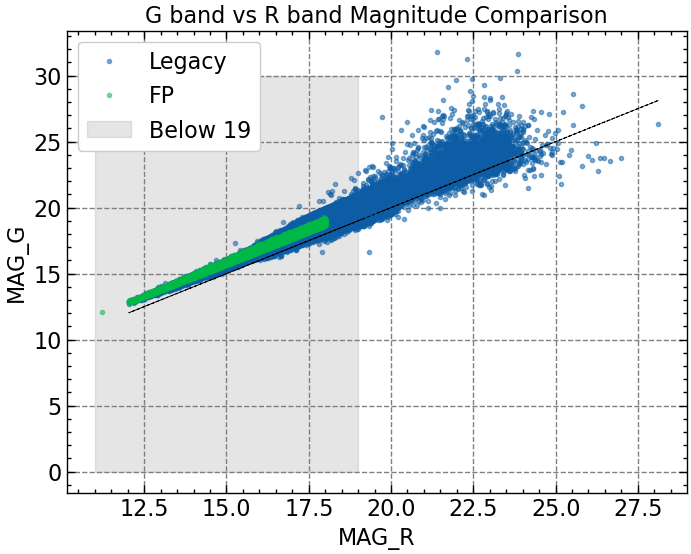

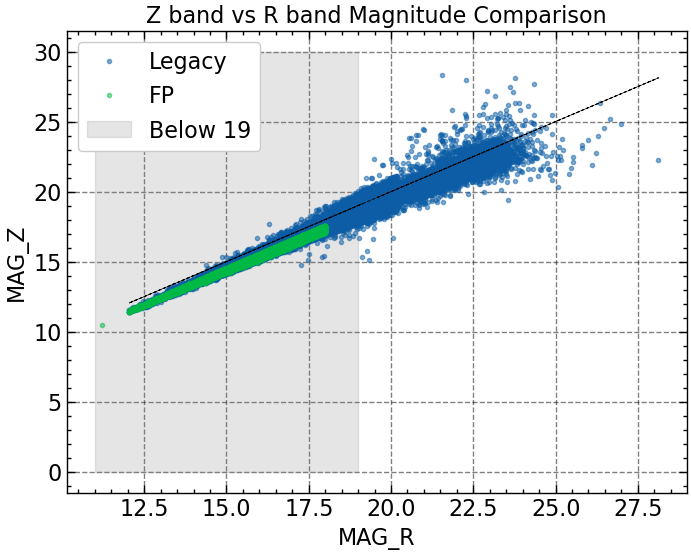

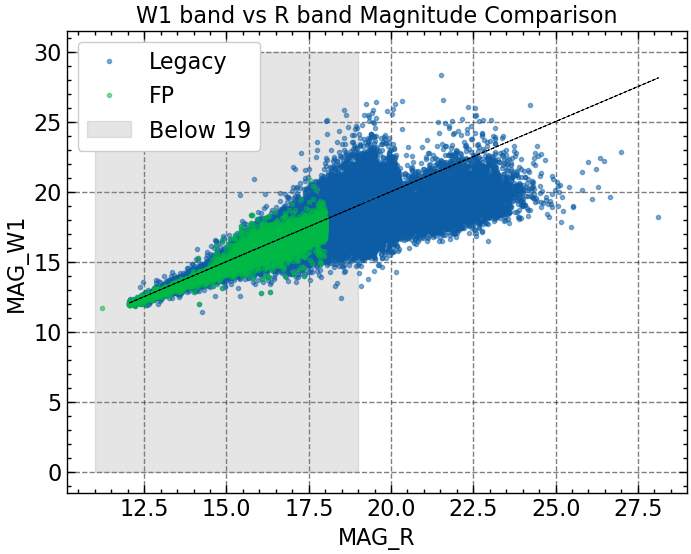

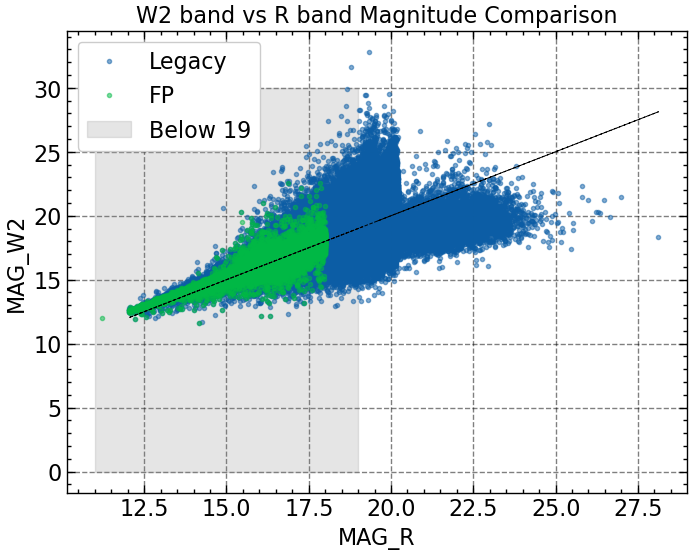

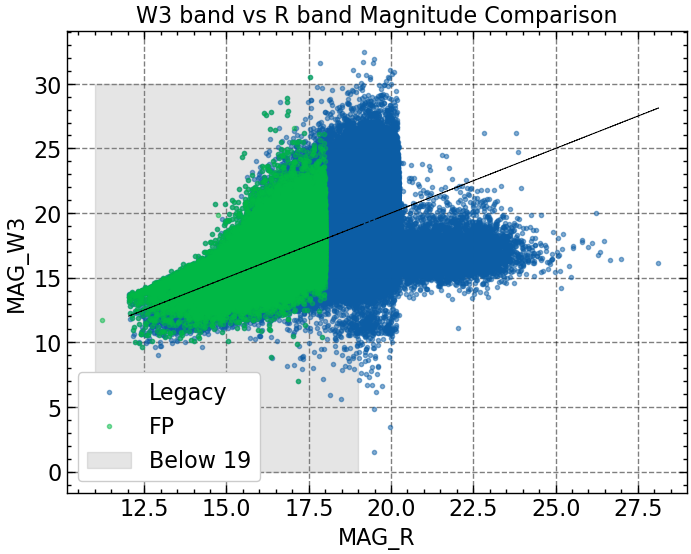

In [70]:
for band in ['G', 'Z', 'W1', 'W2', 'W3']:
    plt.figure()
    plt.plot(legacy_full_filtered['MAG_R'], legacy_full_filtered[f'MAG_{band}'], '.', alpha=0.5, label='Legacy')
    plt.plot(matched_FP_filtered['MAG_R'], matched_FP_filtered[f'MAG_{band}'], '.', alpha=0.5, label='FP')
    plt.plot(legacy_full_filtered['MAG_R'], legacy_full_filtered['MAG_R'], 'k--', lw=0.7)
    plt.fill_between([11, 19], [30, 30], alpha=0.2, color='gray', label='Below 19')
    plt.xlabel('MAG_R')
    plt.ylabel(f'MAG_{band}')
    plt.title(f'{band} band vs R band Magnitude Comparison')
    plt.legend()
    plt.show()

In [67]:
mag_linspace = np.linspace(12,28,100)
bright_mag = 19
weights = np.exp(-2 * (mag_linspace - bright_mag))

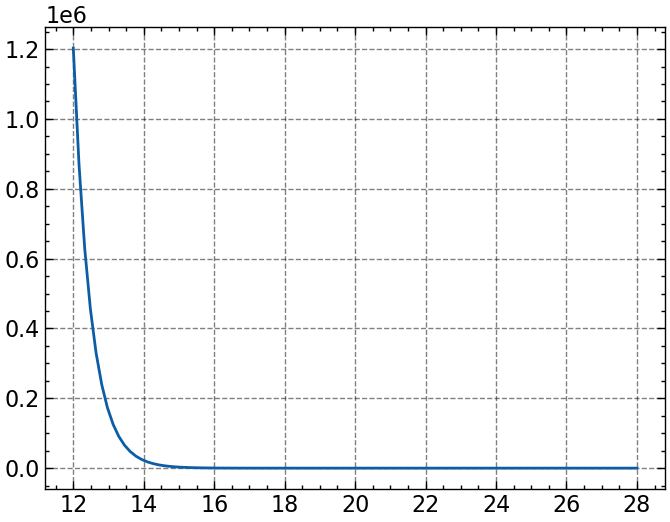

In [68]:
plt.plot(mag_linspace, weights)

In [63]:
def inverse_frequency_weights(mag, n_bins=20):
    """
    Weights inversely proportional to frequency in magnitude bins.
    Bright (rare) objects get higher weights.
    """
    hist, bin_edges = np.histogram(mag, bins=n_bins)
    bin_indices = np.digitize(mag, bin_edges[:-1]) - 1
    bin_indices = np.clip(bin_indices, 0, len(hist)-1)
    
    weights = 1.0 / (hist[bin_indices] + 1)
    weights = weights / weights.mean()  # Normalize to mean=1
    
    return weights

def sigmoid_weights(mag, center=18, steepness=2.0, direction='bright'):
    """
    Sigmoid weighting that transitions around a center magnitude.
    
    Parameters:
    - center: magnitude where transition occurs (e.g., 18 for PV sample)
    - steepness: how sharp the transition is (higher = sharper)
    - direction: 'bright' (weight brighter objects) or 'faint' (weight fainter)
    """
    z = steepness * (mag - center)
    
    if direction == 'bright':
        # Higher weight for mag < center (brighter objects)
        weights = 1 / (1 + np.exp(z))
    else:
        # Higher weight for mag > center (fainter objects)
        weights = 1 / (1 + np.exp(-z))
    
    # Normalize
    weights = weights / weights.mean()
    
    return weights

In [141]:
np.mean(sigmoid_wts)

0.9999995

Text(0.5, 1.0, 'Sigmoid Weights vs MAG_G Distribution')

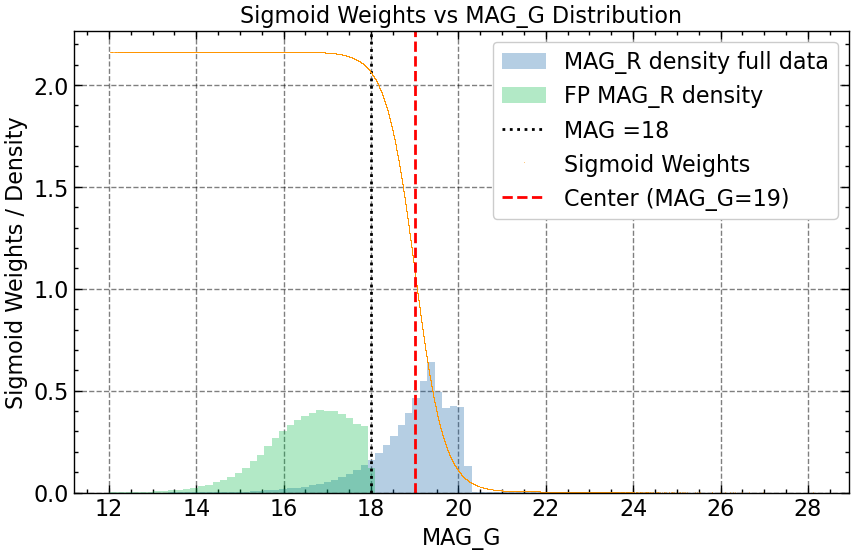

In [69]:
center= 19
sigmoid_wts = sigmoid_weights(legacy_full_filtered['MAG_R'], center=center, steepness=3.0, direction='bright')
plt.figure(figsize=(10, 6))
x = legacy_full_filtered['MAG_R']
w = sigmoid_wts
bins =np.linspace(12,22,60) 
#w_norm = (sigmoid_wts - sigmoid_wts.min()) / (sigmoid_wts.max() - sigmoid_wts.min())
counts, bins, _ = plt.hist(x, bins=bins, density=True, alpha=0.3, label='MAG_R density full data')
plt.hist(matched_FP_filtered['MAG_R'], bins=bins, density=True, alpha=0.3, label='FP MAG_R density')
hist_y = counts / counts.max()  # normalize histogram to max 1

plt.axvline(18, color='k', linestyle=':', label='MAG =18')
plt.plot(x, sigmoid_wts,',', alpha=0.5, label='Sigmoid Weights')
#plt.hist(x, bins=30, alpha=0.3, label='MAG_G Distribution', density=True)
plt.axvline(center, color='red', linestyle='--', label='Center (MAG_G=19)')
plt.legend()
plt.ylabel('Sigmoid Weights / Density')
plt.xlabel('MAG_G')
plt.title('Sigmoid Weights vs MAG_G Distribution')

In [111]:
import pickle

with open('n_z_spline.pkl', 'rb') as f:
    spline = pickle.load(f)

def n_z_pdf(redshift):
    normed = np.maximum(0, spline(redshift))/np.mean(np.maximum(0, spline(redshift)))
    #pdf_clipped = np.clip(normed, 0.01, 10)  # Clip values to avoid extreme weights
    #pdf_normed = pdf_clipped / np.mean(pdf_clipped)
    return normed

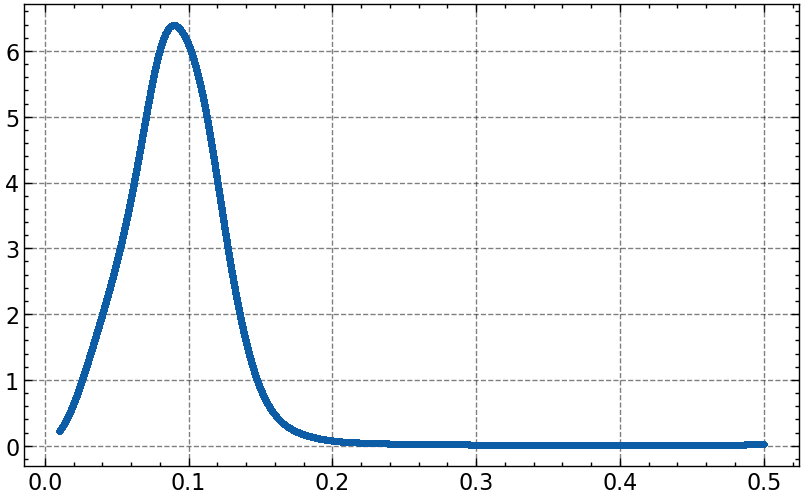

In [107]:
plt.figure(figsize=(10, 6) )
plt.plot(DR1_full_filtered['Z'], n_z_pdf(DR1_full_filtered['Z']),'.')